In [ ]:
import pandas as pd
import os
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, recall_score, precision_score, f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform
from xgboost import XGBClassifier
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

this parte uo will conect to your drive and take the dataset


In [ ]:
# Conexão do colab com o drive
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
df = pd.read_csv("")

In [ ]:
df.info()

In [ ]:
df.head()

In [ ]:
df.describe()

## AUXILIARY FUNCTIONS

In [ ]:
# Binary: recall of the Failure class (1)

recall_fault_scorer = make_scorer(recall_score, pos_label=1)

# Multiclass: focus on classes 1, 2, and 3
# Since you map 1..7 -> 0..6, then:
# class 1 -> 0
# class 2 -> 1
# class 3 -> 2
C123_MAPPED = [0, 1, 2]

def recall_c123_macro(y_true, y_pred):
    return recall_score(
        y_true,
        y_pred,
        labels=C123_MAPPED,
        average="macro",
        zero_division=0
    )

def f1_macro_all(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def multiclass_focus_score(y_true, y_pred):
    """
    Score combinado para diagnóstico multiclasse.
    Dá mais peso às classes difíceis (1,2,3) sem ignorar o desempenho global.
    """
    rec_123 = recall_c123_macro(y_true, y_pred)
    f1_all = f1_macro_all(y_true, y_pred)
    return 0.6 * rec_123 + 0.4 * f1_all

multiclass_focus_scorer = make_scorer(multiclass_focus_score)

def build_sample_weights_multiclass(y, boost_labels=(0, 1, 2), boost_factor=2.0):
    """
    Aumenta o peso das classes mais difíceis.
    y já deve estar mapeado para 0..6.
    """
    weights = np.ones(len(y), dtype=float)
    mask = np.isin(y, boost_labels)
    weights[mask] = boost_factor
    return weights

def top_features_from_permutation(model, X, y, scoring, n_repeats=10, random_state=42):
    """
    Calcula permutation importance e retorna dataframe ordenado.
    """
    result = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    df_imp = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    return df_imp


def evaluate_binary_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    return {
        "accuracy": report["accuracy"],
        "recall_fault": report["1"]["recall"],
        "precision_fault": report["1"]["precision"],
        "f1_fault": report["1"]["f1-score"]
    }


def evaluate_multiclass_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    return {
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "recall_c1": report["0"]["recall"],  # class 1 original -> 0
        "recall_c2": report["1"]["recall"],  # class 2 original -> 1
        "recall_c3": report["2"]["recall"],  # class 3 original -> 2
    }


def run_complete_pipeline(detector_model, faults_model,
                          X_train_bin, y_train_bin,
                          X_train_faults, y_train_faults_0,
                          X_test, y_test_multi):
    """
    Treina detector e classificador multiclasse, executa pipeline completo e retorna métricas.
    """
    detector_model.fit(X_train_bin, y_train_bin)
    faults_model.fit(X_train_faults, y_train_faults_0)

    pred_bin_test = detector_model.predict(X_test)

    final_pred_multi = np.zeros(len(X_test), dtype=int)
    idx_pred_fault = np.where(pred_bin_test == 1)[0]

    if len(idx_pred_fault) > 0:
        proba_pipeline_faults = faults_model.predict_proba(X_test.iloc[idx_pred_fault])
        pred_pipeline_faults_0 = np.argmax(proba_pipeline_faults, axis=1)
        final_pred_multi[idx_pred_fault] = pred_pipeline_faults_0 + 1

    report = classification_report(y_test_multi, final_pred_multi, output_dict=True, zero_division=0)

    return {
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "recall_1": report["1"]["recall"],
        "recall_2": report["2"]["recall"],
        "recall_3": report["3"]["recall"],
    }

In [ ]:
def prepare_data_time_splits(
    df,
    timestamp_col="Timestamp",
    target_col="Fault_Label",
    train_ratio=0.6,
    val_ratio=0.2,
):
    # 1) copy and temporal sorting
    df_ = df.copy()
    df_[timestamp_col] = pd.to_datetime(df_[timestamp_col], errors="coerce")
    df_ = df_.sort_values(timestamp_col).reset_index(drop=True)

    # 2) features and targets
    feature_cols = [c for c in df_.columns if c not in [target_col, timestamp_col]]
    X = df_[feature_cols]

    y_multi = df_[target_col].astype(int)
    y_bin = (y_multi != 0).astype(int)

    # 3) temporal split: train / validation / test
    n = len(df_)
    train_end = int(train_ratio * n)
    val_end = int((train_ratio + val_ratio) * n)

    X_train, y_train_bin, y_train_multi = X.iloc[:train_end], y_bin.iloc[:train_end], y_multi.iloc[:train_end]
    X_val,   y_val_bin,   y_val_multi   = X.iloc[train_end:val_end], y_bin.iloc[train_end:val_end], y_multi.iloc[train_end:val_end]
    X_test,  y_test_bin,  y_test_multi  = X.iloc[val_end:], y_bin.iloc[val_end:], y_multi.iloc[val_end:]

    print("Distribuição (binário):")
    print("Treino:\n", y_train_bin.value_counts(normalize=True))
    print("Val:\n", y_val_bin.value_counts(normalize=True))
    print("Teste:\n", y_test_bin.value_counts(normalize=True))

    return {
        "df_sorted": df_,
        "feature_cols": feature_cols,
        "X_train": X_train, "y_train_bin": y_train_bin, "y_train_multi": y_train_multi,
        "X_val": X_val, "y_val_bin": y_val_bin, "y_val_multi": y_val_multi,
        "X_test": X_test, "y_test_bin": y_test_bin, "y_test_multi": y_test_multi,
    }


In [ ]:
def plot_matrix_bin(cm):
  plt.figure(figsize=(6,5))

  sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Falha"],
    yticklabels=["Normal", "Falha"]
  )

  plt.xlabel("Predicted label")
  plt.ylabel("True label")
  plt.title("Matriz de Confusão — Detecção Binária de Falhas (Normal vs Falha)")

  plt.tight_layout()
  plt.show()


def plot_matrix_multiclass(cm):
    plt.figure(figsize=(7,6))

    classes = ["1", "2", "3", "4", "5", "6", "7"]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Matriz de Confusão — Diagnóstico Multiclasse de Falhas (Classes 1–7)")

    plt.tight_layout()
    plt.show()


def plot_matrix_pipeline(cm):
    plt.figure(figsize=(8,6))

    classes = [
        "Normal",
        "1", "2", "3", "4", "5", "6", "7"
    ]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Matriz de Confusão — Pipeline Completo de Detecção e Diagnóstico de Falhas")

    plt.tight_layout()
    plt.show()

In [ ]:
data = prepare_data_time_splits(df, train_ratio=0.6, val_ratio=0.2)

X_train = data["X_train"]; y_train_bin = data["y_train_bin"]
X_val   = data["X_val"];   y_val_bin   = data["y_val_bin"]
X_test  = data["X_test"];  y_test_bin  = data["y_test_bin"]

y_train_multi = data["y_train_multi"]
y_val_multi   = data["y_val_multi"]
y_test_multi  = data["y_test_multi"]

# ML Code

## Random Forest

### Baseline configuration

#### 1.Detection (Normal vs. Fault)

In [ ]:
detector = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

detector.fit(X_train, y_train_bin)

pred_test_bin = detector.predict(X_test)

print("\n=== MODELO 1: Detecção (Normal vs Falha) - Teste ===")
print(classification_report(y_test_bin, pred_test_bin, digits=4))



=== MODELO 1: Detecção (Normal vs Falha) - Teste ===
              precision    recall  f1-score   support

           0     0.8685    0.9582    0.9111      1268
           1     0.9118    0.7486    0.8222       732

    accuracy                         0.8815      2000
   macro avg     0.8901    0.8534    0.8667      2000
weighted avg     0.8843    0.8815    0.8786      2000



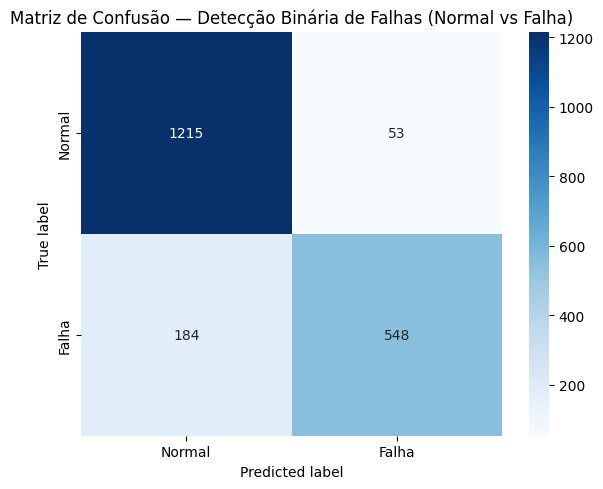

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, pred_test_bin))

#### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

detector.fit(X_train_faults, y_train_faults)
pred_test_faults = detector.predict(X_test_faults_true)

print("\n=== MODELO 2: Diagnóstico (Falhas 1–7) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))



=== MODELO 2: Diagnóstico (Falhas 1–7) ===
              precision    recall  f1-score   support

           1     0.8077    0.7778    0.7925       108
           2     0.8319    0.8785    0.8545       107
           3     0.8706    0.8043    0.8362        92
           4     1.0000    1.0000    1.0000       100
           5     0.9658    0.9741    0.9700       116
           6     0.9633    1.0000    0.9813       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9208       732
   macro avg     0.9199    0.9193    0.9192       732
weighted avg     0.9201    0.9208    0.9201       732



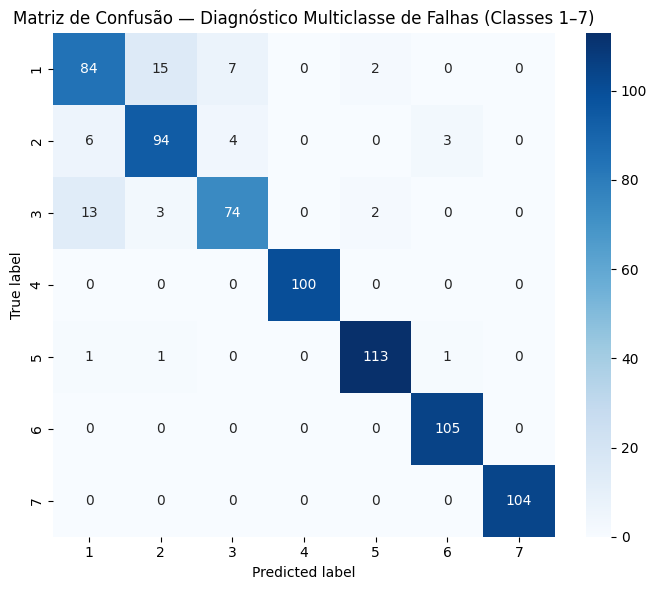

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults))

####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is



In [ ]:
final_pred_multi = np.zeros(len(X_test), dtype=int)

idx_pred_fault = np.where(pred_test_bin == 1)[0]

if len(idx_pred_fault) > 0:
    final_pred_multi[idx_pred_fault] = detector.predict(X_test.iloc[idx_pred_fault])

print("\n=== PIPELINE COMPLETO (0 vs 1–7) no conjunto de teste ===")
print(classification_report(y_test_multi, final_pred_multi, digits=4))



=== PIPELINE COMPLETO (0 vs 1–7) no conjunto de teste ===
              precision    recall  f1-score   support

           0     0.8685    0.9582    0.9111      1268
           1     0.5200    0.1204    0.1955       108
           2     0.7681    0.4953    0.6023       107
           3     0.7600    0.6196    0.6826        92
           4     1.0000    1.0000    1.0000       100
           5     0.9032    0.9655    0.9333       116
           6     0.9519    0.9429    0.9474       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.8765      2000
   macro avg     0.8465    0.7627    0.7840      2000
weighted avg     0.8591    0.8765    0.8577      2000



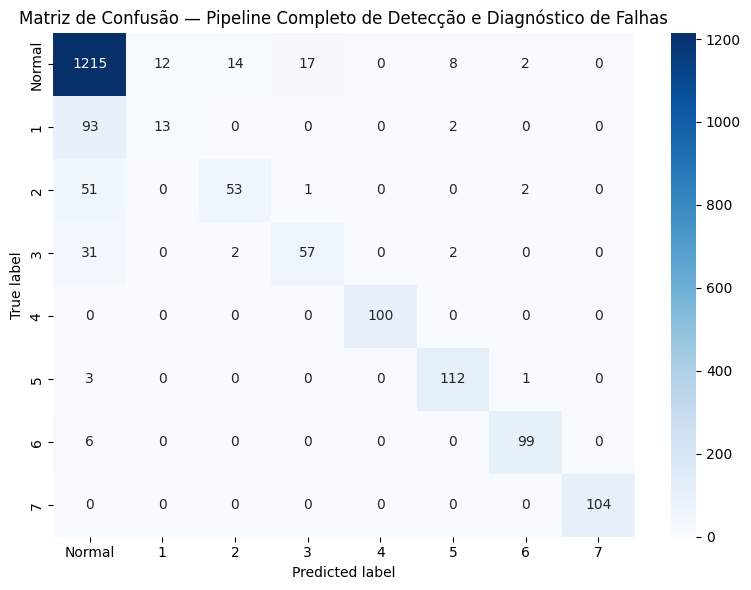

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi))

### recall_fault_scorer configuration

#### 2º Version

##### 1.Detection (Normal vs. Fault)

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)

rf_detector = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist_detector_rf = {
    "n_estimators": randint(200, 700),
    "max_depth": [None, 10, 20, 30, 40, 60],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 12),
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

search_detector_rf = RandomizedSearchCV(
    estimator=rf_detector,
    param_distributions=param_dist_detector_rf,
    n_iter=30,
    scoring=recall_fault_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_detector_rf.fit(X_train, y_train_bin)

best_rf_detector = search_detector_rf.best_estimator_

print("\n[RF Detector] Melhores parâmetros:")
print(search_detector_rf.best_params_)
print(f"[RF Detector] Melhor recall médio (CV): {search_detector_rf.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

[RF Detector] Melhores parâmetros:
{'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 8, 'n_estimators': 240}
[RF Detector] Melhor recall médio (CV): 0.7691


In [ ]:
pred_test_bin_rf = best_rf_detector.predict(X_test)

print("\n=== RF DETECTOR (Teste) ===")
print(classification_report(y_test_bin, pred_test_bin_rf, digits=4))


=== RF DETECTOR (Teste) ===
              precision    recall  f1-score   support

           0     0.8865    0.9298    0.9076      1268
           1     0.8672    0.7937    0.8288       732

    accuracy                         0.8800      2000
   macro avg     0.8768    0.8618    0.8682      2000
weighted avg     0.8794    0.8800    0.8788      2000



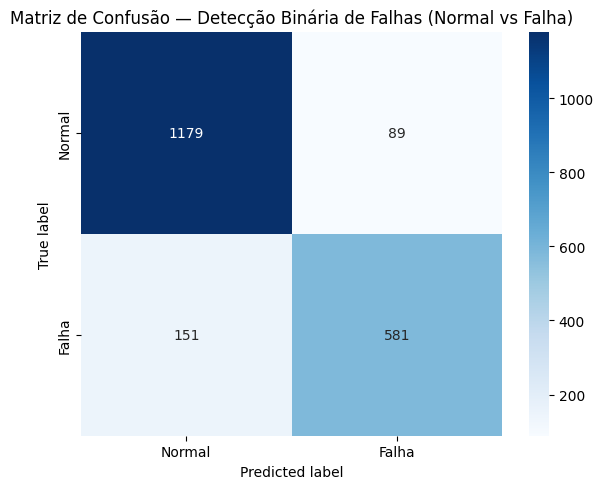

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, pred_test_bin_rf))

#####  2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

y_train_faults_0 = (y_train_faults - 1).astype(int)
y_test_faults_0  = (y_test_faults_true - 1).astype(int)

sample_weight_rf_faults = build_sample_weights_multiclass(
    y_train_faults_0.values,
    boost_labels=(0, 1, 2),
    boost_factor=2.0
)

rf_faults = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist_faults_rf = {
    "n_estimators": randint(200, 700),
    "max_depth": [None, 10, 20, 30, 40, 60],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 12),
    "max_features": ["sqrt", "log2"]
}

search_faults_rf = RandomizedSearchCV(
    estimator=rf_faults,
    param_distributions=param_dist_faults_rf,
    n_iter=30,
    scoring=multiclass_focus_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_faults_rf.fit(
    X_train_faults,
    y_train_faults_0,
    sample_weight=sample_weight_rf_faults
)

best_rf_faults = search_faults_rf.best_estimator_

print("\n[RF Multiclasse] Melhores parâmetros:")
print(search_faults_rf.best_params_)
print(f"[RF Multiclasse] Melhor score médio (CV): {search_faults_rf.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

[RF Multiclasse] Melhores parâmetros:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 488}
[RF Multiclasse] Melhor score médio (CV): 0.8844


In [ ]:
pred_test_faults_rf_0 = best_rf_faults.predict(X_test_faults_true)
pred_test_faults_rf = pred_test_faults_rf_0 + 1

print("\n=== RF DIAGNÓSTICO (Teste, apenas falhas reais) ===")
print(classification_report(y_test_faults_true, pred_test_faults_rf, digits=4))


=== RF DIAGNÓSTICO (Teste, apenas falhas reais) ===
              precision    recall  f1-score   support

           1     0.8058    0.7685    0.7867       108
           2     0.8246    0.8785    0.8507       107
           3     0.8621    0.8152    0.8380        92
           4     1.0000    1.0000    1.0000       100
           5     0.9652    0.9569    0.9610       116
           6     0.9633    1.0000    0.9813       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9180       732
   macro avg     0.9173    0.9170    0.9168       732
weighted avg     0.9176    0.9180    0.9175       732



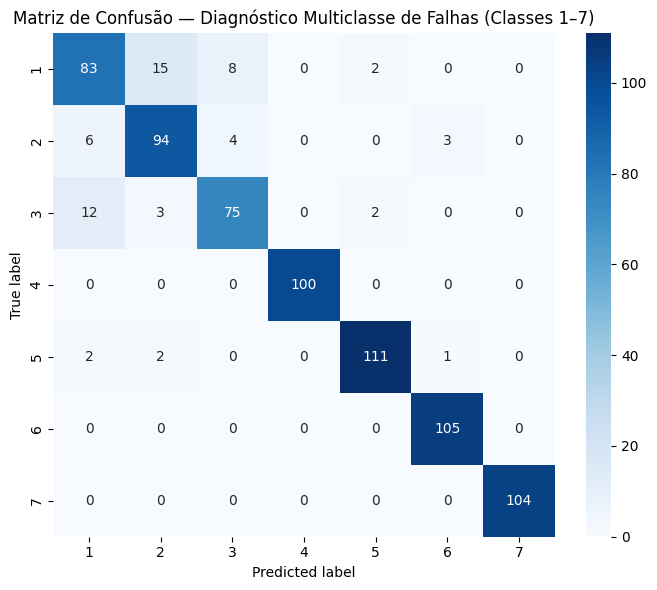

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults_rf))

##### SPECIALIST FOR CLASSES 1, 2, AND 3

In [ ]:
mask_123_train = y_train_faults.isin([1, 2, 3])
mask_123_test  = y_test_faults_true.isin([1, 2, 3])

X_train_123_rf = X_train_faults.loc[mask_123_train]
y_train_123_rf = y_train_faults.loc[mask_123_train].astype(int) - 1

X_test_123_rf = X_test_faults_true.loc[mask_123_test]
y_test_123_rf = y_test_faults_true.loc[mask_123_test].astype(int) - 1

rf_123 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist_123_rf = {
    "n_estimators": randint(200, 700),
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 12),
    "max_features": ["sqrt", "log2"]
}

search_123_rf = RandomizedSearchCV(
    estimator=rf_123,
    param_distributions=param_dist_123_rf,
    n_iter=20,
    scoring=make_scorer(recall_score, average="macro", zero_division=0),
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_123_rf.fit(X_train_123_rf, y_train_123_rf)

best_rf_123 = search_123_rf.best_estimator_

print("\n[RF Especialista 1-3] Melhores parâmetros:")
print(search_123_rf.best_params_)
print(f"[RF Especialista 1-3] Melhor recall macro (CV): {search_123_rf.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

[RF Especialista 1-3] Melhores parâmetros:
{'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 208}
[RF Especialista 1-3] Melhor recall macro (CV): 0.8563


##### 3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
final_pred_multi_rf = np.zeros(len(X_test), dtype=int)

pred_bin_test_rf = best_rf_detector.predict(X_test)

idx_pred_fault_rf = np.where(pred_bin_test_rf == 1)[0]

if len(idx_pred_fault_rf) > 0:
    pred_faults_main_rf_0 = best_rf_faults.predict(X_test.iloc[idx_pred_fault_rf])
    pred_faults_main_rf = pred_faults_main_rf_0 + 1

    mask_main_123_rf = np.isin(pred_faults_main_rf, [1, 2, 3])

    if mask_main_123_rf.any():
        idx_123_rf = idx_pred_fault_rf[mask_main_123_rf]
        pred_123_rf = best_rf_123.predict(X_test.iloc[idx_123_rf]) + 1
        pred_faults_main_rf[mask_main_123_rf] = pred_123_rf

    final_pred_multi_rf[idx_pred_fault_rf] = pred_faults_main_rf

print("\n=== PIPELINE COMPLETO RF (Config 3 melhorada) ===")
print(classification_report(y_test_multi, final_pred_multi_rf, digits=4))


=== PIPELINE COMPLETO RF (Config 3 melhorada) ===
              precision    recall  f1-score   support

           0     0.8865    0.9298    0.9076      1268
           1     0.4833    0.2685    0.3452       108
           2     0.6897    0.5607    0.6186       107
           3     0.6966    0.6739    0.6851        92
           4     1.0000    1.0000    1.0000       100
           5     0.8880    0.9569    0.9212       116
           6     0.9429    0.9429    0.9429       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.8720      2000
   macro avg     0.8234    0.7916    0.8026      2000
weighted avg     0.8601    0.8720    0.8636      2000



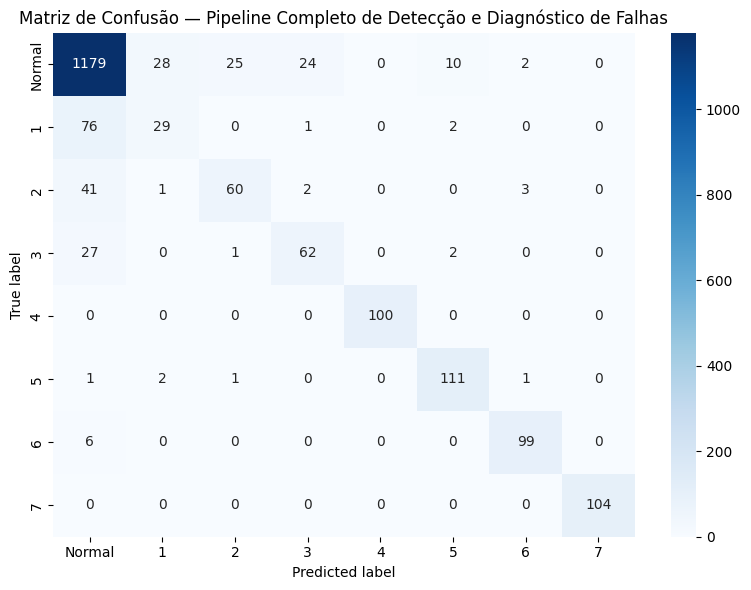

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi_rf))

#### 1º Version

##### 1.Detection (Normal vs. Fault)

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": randint(200, 700),
    "max_depth": [None, 10, 20, 30, 40, 60],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 12),
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

recall_fault_scorer = make_scorer(recall_score, pos_label=1)

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=recall_fault_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train_bin)

best_rf_detector = search.best_estimator_

print("Melhores parâmetros encontrados:")
print(search.best_params_)
print(f"Melhor recall médio (CV) para classe Falha (1): {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Melhores parâmetros encontrados:
{'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 8, 'n_estimators': 240}
Melhor recall médio (CV) para classe Falha (1): 0.7691


In [ ]:
pred_test_bin_opt = best_rf_detector.predict(X_test)

print("\n=== MODELO 1 OTIMIZADO (Normal vs Falha) ===")
print(classification_report(y_test_bin, pred_test_bin_opt, digits=4))



=== MODELO 1 OTIMIZADO (Normal vs Falha) ===
              precision    recall  f1-score   support

           0     0.8865    0.9298    0.9076      1268
           1     0.8672    0.7937    0.8288       732

    accuracy                         0.8800      2000
   macro avg     0.8768    0.8618    0.8682      2000
weighted avg     0.8794    0.8800    0.8788      2000



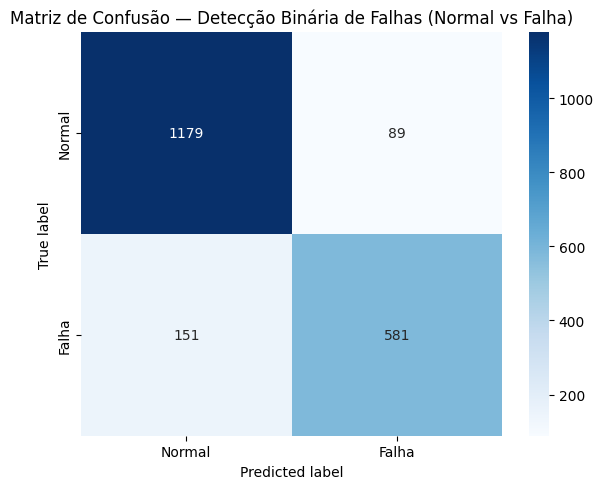

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, pred_test_bin_opt))

In [ ]:
# 1) Impurity-based importance (Gini)
importances = pd.Series(
    best_rf_detector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features (impurity-based) - DETECTOR:")
print(importances.head(15))


Top 15 features (impurity-based) - DETECTOR:
Air_Pressure              0.175208
Oil_Pressure              0.154323
Vibration_Y               0.086650
Vibration_X               0.076725
Vibration_Z               0.059399
Fuel_Flow                 0.056941
Cylinder1_Exhaust_Temp    0.052281
Cylinder2_Exhaust_Temp    0.051613
Oil_Temp                  0.050277
Cylinder3_Exhaust_Temp    0.042575
Cylinder2_Pressure        0.038046
Cylinder4_Exhaust_Temp    0.036754
Cylinder4_Pressure        0.036206
Cylinder3_Pressure        0.031727
Cylinder1_Pressure        0.028734
dtype: float64


In [ ]:
perm = permutation_importance(
    best_rf_detector,
    X_val,
    y_val_bin,
    scoring=recall_fault_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importances = pd.Series(
    perm.importances_mean,
    index=X_val.columns
).sort_values(ascending=False)

print("\nTop 15 features (permutation importance - baseado em recall de falha) - DETECTOR:")
print(perm_importances.head(15))


Top 15 features (permutation importance - baseado em recall de falha) - DETECTOR:
Air_Pressure              0.116595
Oil_Pressure              0.041345
Cylinder3_Exhaust_Temp    0.024607
Fuel_Flow                 0.024320
Cylinder4_Pressure        0.022175
Cylinder2_Pressure        0.020029
Cylinder2_Exhaust_Temp    0.019027
Cylinder4_Exhaust_Temp    0.017597
Cylinder3_Pressure        0.017597
Cylinder1_Pressure        0.015165
Cylinder1_Exhaust_Temp    0.012446
Oil_Temp                  0.010157
Ambient_Temp              0.000715
Engine_Load              -0.000143
Shaft_RPM                -0.000858
dtype: float64


Após a otimização dos hiperparâmetros com foco no recall da classe de falha, observou-se um aumento significativo da capacidade de detecção de eventos defeituosos, à custa de um maior número de alarmes falsos, caracterizando um trade-off típico de sistemas de manutenção preditiva. A análise de importância das variáveis revelou alterações relevantes no ranking das features quando comparadas métricas baseadas em impureza e em permutação. Enquanto a importância baseada em impureza tende a favorecer variáveis com maior variabilidade, a importância por permutação evidenciou sensores cuja perturbação impacta diretamente o recall de falha, como pressão do ar de admissão, pressão do óleo e pressões nos cilindros, reforçando a coerência física do modelo

##### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

search.fit(X_train_faults, y_train_faults)

best_rf_faults = search.best_estimator_

print("\nMelhores parâmetros encontrados (Modelo 2 - falhas 1–7):")
print(search.best_params_)
print(f"Melhor score médio (CV) em f1_macro: {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



Melhores parâmetros encontrados (Modelo 2 - falhas 1–7):
{'class_weight': 'balanced', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 11, 'min_samples_split': 9, 'n_estimators': 388}
Melhor score médio (CV) em f1_macro: nan


In [ ]:
pred_test_faults = best_rf_faults.predict(X_test_faults_true)

print("\n=== MODELO 2 OTIMIZADO: Diagnóstico (Falhas 1–7) no TESTE (apenas falhas reais) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))



=== MODELO 2 OTIMIZADO: Diagnóstico (Falhas 1–7) no TESTE (apenas falhas reais) ===
              precision    recall  f1-score   support

           1     0.7900    0.7315    0.7596       108
           2     0.8036    0.8411    0.8219       107
           3     0.8636    0.8261    0.8444        92
           4     1.0000    1.0000    1.0000       100
           5     0.9496    0.9741    0.9617       116
           6     0.9633    1.0000    0.9813       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9112       732
   macro avg     0.9100    0.9104    0.9099       732
weighted avg     0.9099    0.9112    0.9102       732



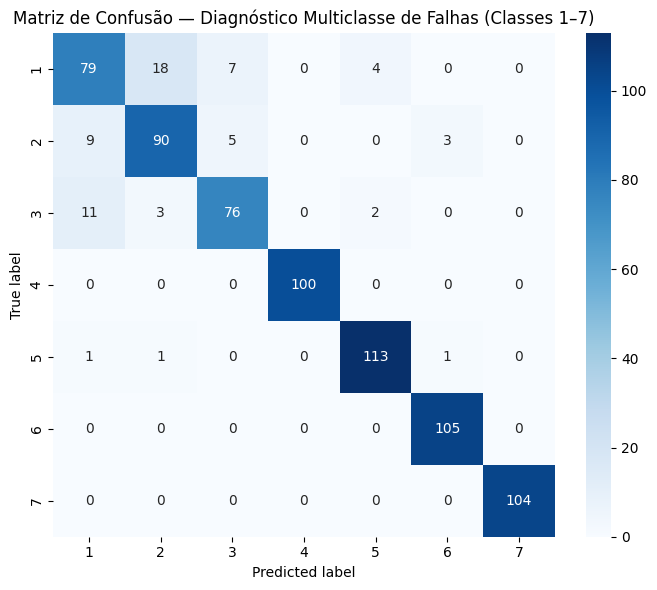

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults))

#####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
final_pred_multi = np.zeros(len(X_test), dtype=int)

pred_bin_test = pred_test_bin_opt

idx_pred_fault = np.where(pred_bin_test == 1)[0]

if len(idx_pred_fault) > 0:
    final_pred_multi[idx_pred_fault] = best_rf_faults.predict(X_test.iloc[idx_pred_fault])

print("\n=== PIPELINE COMPLETO no TESTE (0 vs 1–7) ===")
print(classification_report(y_test_multi, final_pred_multi, digits=4))



=== PIPELINE COMPLETO no TESTE (0 vs 1–7) ===
              precision    recall  f1-score   support

           0     0.8865    0.9298    0.9076      1268
           1     0.4286    0.2500    0.3158       108
           2     0.6875    0.5140    0.5882       107
           3     0.7011    0.6630    0.6816        92
           4     1.0000    1.0000    1.0000       100
           5     0.8626    0.9741    0.9150       116
           6     0.9429    0.9429    0.9429       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.8690      2000
   macro avg     0.8136    0.7842    0.7939      2000
weighted avg     0.8557    0.8690    0.8599      2000



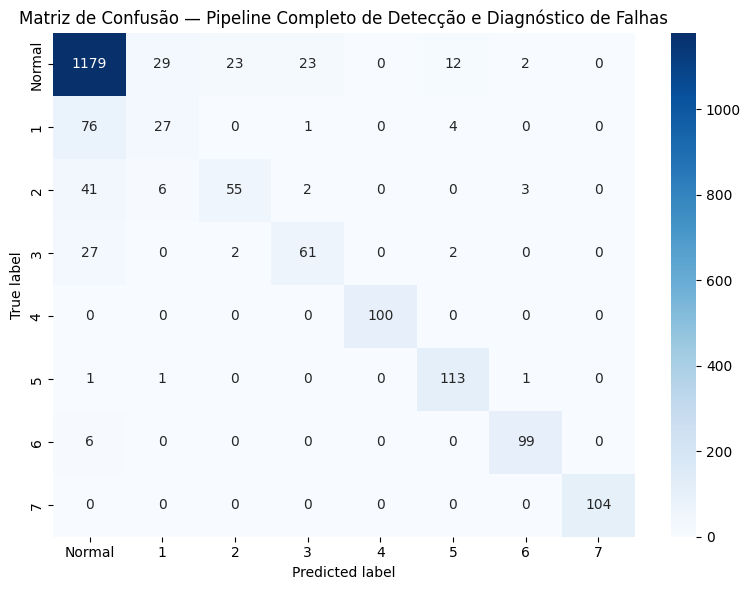

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi))

### scoring="roc_auc" configuration

#### 1.Detection (Normal vs. Fault)

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": randint(200, 700),
    "max_depth": [None, 10, 20, 30, 40, 60],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 12),
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

recall_fault_scorer = make_scorer(recall_score, pos_label=1)

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train_bin)

best_rf_detector = search.best_estimator_

print("Melhores parâmetros encontrados:")
print(search.best_params_)
print(f"Melhor recall médio (CV) para classe Falha (1): {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Melhores parâmetros encontrados:
{'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 366}
Melhor recall médio (CV) para classe Falha (1): 0.9214


In [ ]:
pred_test_bin_opt_2 = best_rf_detector.predict(X_test)

print("\n=== MODELO 1 OTIMIZADO (Normal vs Falha) ===")
print(classification_report(y_test_bin, pred_test_bin_opt_2, digits=4))



=== MODELO 1 OTIMIZADO (Normal vs Falha) ===
              precision    recall  f1-score   support

           0     0.8835    0.9393    0.9106      1268
           1     0.8819    0.7855    0.8309       732

    accuracy                         0.8830      2000
   macro avg     0.8827    0.8624    0.8707      2000
weighted avg     0.8829    0.8830    0.8814      2000



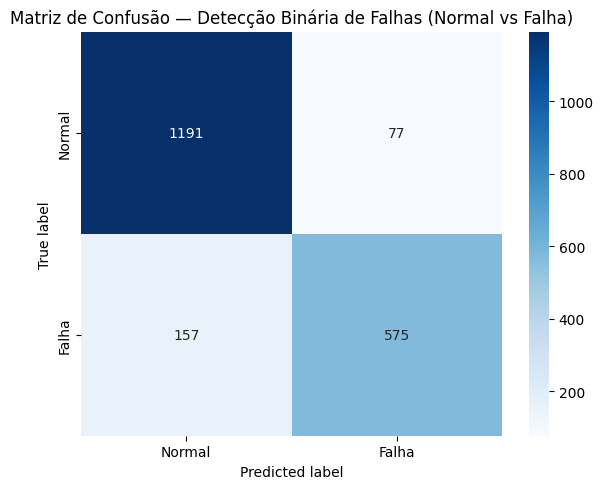

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, pred_test_bin_opt_2))

In [ ]:
importances = pd.Series(
    best_rf_detector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features (impurity-based):")
print(importances.head(15))


Top 15 features (impurity-based):
Air_Pressure              0.167280
Oil_Pressure              0.148628
Vibration_Y               0.082306
Vibration_X               0.075432
Vibration_Z               0.058680
Fuel_Flow                 0.055506
Cylinder2_Exhaust_Temp    0.052666
Oil_Temp                  0.051941
Cylinder1_Exhaust_Temp    0.051620
Cylinder3_Exhaust_Temp    0.044186
Cylinder2_Pressure        0.039607
Cylinder4_Exhaust_Temp    0.038954
Cylinder4_Pressure        0.037405
Cylinder3_Pressure        0.034132
Cylinder1_Pressure        0.030215
dtype: float64


In [ ]:
perm = permutation_importance(
    best_rf_detector,
    X_test,
    y_test_bin,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importances = pd.Series(perm.importances_mean, index=X_test.columns)\
                     .sort_values(ascending=False)

print("\nTop 15 features (permutation importance - baseado em recall de falha):")
print(perm_importances.head(15))


Top 15 features (permutation importance - baseado em recall de falha):
Air_Pressure              0.096967
Oil_Pressure              0.057117
Fuel_Flow                 0.038801
Cylinder2_Pressure        0.017721
Vibration_Y               0.017656
Cylinder2_Exhaust_Temp    0.017601
Cylinder3_Pressure        0.017387
Cylinder4_Exhaust_Temp    0.017364
Cylinder4_Pressure        0.017039
Cylinder3_Exhaust_Temp    0.017039
Cylinder1_Exhaust_Temp    0.014109
Cylinder1_Pressure        0.014038
Vibration_Z               0.013167
Vibration_X               0.011476
Oil_Temp                  0.010347
dtype: float64


#### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

search.fit(X_train_faults, y_train_faults)

best_rf_faults = search.best_estimator_

print("\nMelhores parâmetros encontrados (Modelo 2 - falhas 1–7):")
print(search.best_params_)
print(f"Melhor score médio (CV) em f1_macro: {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



Melhores parâmetros encontrados (Modelo 2 - falhas 1–7):
{'class_weight': 'balanced', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 11, 'min_samples_split': 9, 'n_estimators': 388}
Melhor score médio (CV) em f1_macro: nan


In [ ]:
pred_test_faults = best_rf_faults.predict(X_test_faults_true)

print("\n=== MODELO 2 OTIMIZADO: Diagnóstico (Falhas 1–7) no TESTE (apenas falhas reais) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))



=== MODELO 2 OTIMIZADO: Diagnóstico (Falhas 1–7) no TESTE (apenas falhas reais) ===
              precision    recall  f1-score   support

           1     0.7900    0.7315    0.7596       108
           2     0.8036    0.8411    0.8219       107
           3     0.8636    0.8261    0.8444        92
           4     1.0000    1.0000    1.0000       100
           5     0.9496    0.9741    0.9617       116
           6     0.9633    1.0000    0.9813       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9112       732
   macro avg     0.9100    0.9104    0.9099       732
weighted avg     0.9099    0.9112    0.9102       732



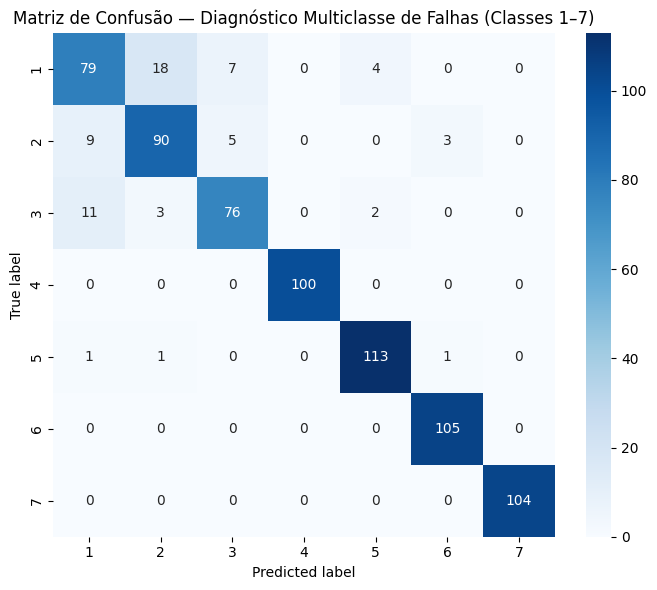

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults))

####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
final_pred_multi = np.zeros(len(X_test), dtype=int)

pred_bin_test = pred_test_bin_opt_2

idx_pred_fault = np.where(pred_bin_test == 1)[0]

if len(idx_pred_fault) > 0:
    final_pred_multi[idx_pred_fault] = best_rf_faults.predict(X_test.iloc[idx_pred_fault])

print("\n=== PIPELINE COMPLETO (0 vs 1–7) no conjunto de teste ===")
print(classification_report(y_test_multi, final_pred_multi, digits=4))



=== PIPELINE COMPLETO (0 vs 1–7) no conjunto de teste ===
              precision    recall  f1-score   support

           0     0.8835    0.9393    0.9106      1268
           1     0.4444    0.2222    0.2963       108
           2     0.7143    0.5140    0.5978       107
           3     0.7349    0.6630    0.6971        92
           4     1.0000    1.0000    1.0000       100
           5     0.8760    0.9741    0.9224       116
           6     0.9429    0.9429    0.9429       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.8735      2000
   macro avg     0.8245    0.7819    0.7959      2000
weighted avg     0.8585    0.8735    0.8623      2000



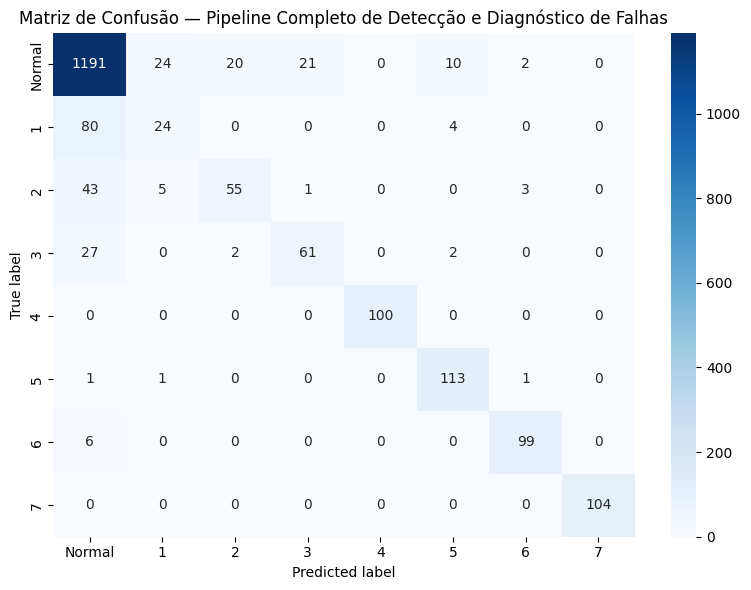

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi))

### Threshold Adjustment Configuration

##### 1.Detection (Normal vs. Fault)

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": randint(200, 700),
    "max_depth": [None, 10, 20, 30, 40, 60],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 12),
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

recall_fault_scorer = make_scorer(recall_score, pos_label=1)

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=recall_fault_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train_bin)

best_rf_detector = search.best_estimator_

print("Melhores parâmetros encontrados:")
print(search.best_params_)
print(f"Melhor recall médio (CV) para classe Falha (1): {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Melhores parâmetros encontrados:
{'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 8, 'n_estimators': 240}
Melhor recall médio (CV) para classe Falha (1): 0.7691


##### Varying the threshold

###### 1º Version

In [ ]:
proba_val = best_rf_detector.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)

rows = []
for t in thresholds:
    y_pred_t = (proba_val >= t).astype(int)

    rec = recall_score(y_val_bin, y_pred_t, zero_division=0)
    prec = precision_score(y_val_bin, y_pred_t, zero_division=0)
    f1 = f1_score(y_val_bin, y_pred_t, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_val_bin, y_pred_t).ravel()

    rows.append({
        "threshold": t,
        "recall_fault": rec,
        "precision_fault": prec,
        "f1_fault": f1,
        "FP": fp,
        "FN": fn
    })

df_thr = pd.DataFrame(rows)
df_thr.sort_values("recall_fault", ascending=False).head(10)

,threshold,recall_fault,precision_fault,f1_fault,FP,FN
0,0.05,1.000000,0.349500,0.517970,1301,0
1,0.10,0.991416,0.401739,0.571782,1032,6
2,0.15,0.957082,0.523884,0.677126,608,30
3,0.20,0.922747,0.598330,0.725943,433,54
4,0.25,0.895565,0.665957,0.763880,314,73
5,0.30,0.881259,0.722157,0.793814,237,83
6,0.35,0.862661,0.752809,0.804000,198,96
7,0.40,0.846924,0.786189,0.815427,161,107
8,0.45,0.822604,0.829726,0.826149,118,124
9,0.50,0.799714,0.865325,0.831227,87,140


In [ ]:
df_ok = df_thr[df_thr["FP"] <= 150]
best_row = df_ok.loc[df_ok["recall_fault"].idxmax()]

best_row

,8
threshold,0.450000
recall_fault,0.822604
precision_fault,0.829726
f1_fault,0.826149
FP,118.000000
FN,124.000000


In [ ]:
threshold_opt = float(best_row["threshold"])
print("Threshold escolhido:", threshold_opt)

Threshold escolhido: 0.45


In [ ]:
proba_test = best_rf_detector.predict_proba(X_test)[:, 1]
y_test_pred = (proba_test >= threshold_opt).astype(int)

print("=== RESULTADO FINAL (TESTE) ===")
print(confusion_matrix(y_test_bin, y_test_pred))
print(classification_report(y_test_bin, y_test_pred, digits=4))


=== RESULTADO FINAL (TESTE) ===
[[1152  116]
 [ 133  599]]
              precision    recall  f1-score   support

           0     0.8965    0.9085    0.9025      1268
           1     0.8378    0.8183    0.8279       732

    accuracy                         0.8755      2000
   macro avg     0.8671    0.8634    0.8652      2000
weighted avg     0.8750    0.8755    0.8752      2000



In [ ]:
importances = pd.Series(
    best_rf_detector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features (impurity-based) - DETECTOR:")
print(importances.head(15))



Top 15 features (impurity-based) - DETECTOR:
Air_Pressure              0.175208
Oil_Pressure              0.154323
Vibration_Y               0.086650
Vibration_X               0.076725
Vibration_Z               0.059399
Fuel_Flow                 0.056941
Cylinder1_Exhaust_Temp    0.052281
Cylinder2_Exhaust_Temp    0.051613
Oil_Temp                  0.050277
Cylinder3_Exhaust_Temp    0.042575
Cylinder2_Pressure        0.038046
Cylinder4_Exhaust_Temp    0.036754
Cylinder4_Pressure        0.036206
Cylinder3_Pressure        0.031727
Cylinder1_Pressure        0.028734
dtype: float64


###### 2º Version

In [ ]:
def build_threshold_table(y_true_bin, proba_fault, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)

    rows = []
    for t in thresholds:
        y_pred = (proba_fault >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred).ravel()

        rows.append({
            "threshold": float(t),
            "recall_fault": recall_score(y_true_bin, y_pred, zero_division=0),
            "precision_fault": precision_score(y_true_bin, y_pred, zero_division=0),
            "f1_fault": f1_score(y_true_bin, y_pred, zero_division=0),
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        })
    return pd.DataFrame(rows)

def pick_threshold_under_fp(df_thr, fp_limit):
    df_ok = df_thr[df_thr["FP"] <= fp_limit].copy()
    if df_ok.empty:
        return None

    df_ok = df_ok.sort_values(
        by=["recall_fault", "f1_fault", "precision_fault", "threshold"],
        ascending=[False, False, False, False]
    )
    return df_ok.iloc[0]

In [ ]:
fp_limits = [100, 125, 150, 175, 200, 300]

proba_val = best_rf_detector.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)
df_thr = build_threshold_table(y_val_bin, proba_val, thresholds=thresholds)

results = []

proba_test = best_rf_detector.predict_proba(X_test)[:, 1]

for lim in fp_limits:
    best_row = pick_threshold_under_fp(df_thr, fp_limit=lim)

    if best_row is None:
        results.append({
            "fp_limit": lim,
            "status": "SEM SOLUÇÃO (nenhum threshold atende FP)",
        })
        continue

    threshold_opt = float(best_row["threshold"])

       y_test_pred = (proba_test >= threshold_opt).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_bin, y_test_pred).ravel()

    results.append({
        "fp_limit": lim,
        "threshold_opt": threshold_opt,

        "test_recall_fault": recall_score(y_test_bin, y_test_pred, zero_division=0),
        "test_precision_fault": precision_score(y_test_bin, y_test_pred, zero_division=0),
        "test_f1_fault": f1_score(y_test_bin, y_test_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test_bin, y_test_pred),
        "test_TN": int(tn), "test_FP": int(fp), "test_FN": int(fn), "test_TP": int(tp),

        "val_recall_fault": float(best_row["recall_fault"]),
        "val_precision_fault": float(best_row["precision_fault"]),
        "val_f1_fault": float(best_row["f1_fault"]),
        "val_FP": int(best_row["FP"]),
        "val_FN": int(best_row["FN"]),
    })

df_sweep = pd.DataFrame(results)
df_sweep


,fp_limit,threshold_opt,test_recall_fault,test_precision_fault,test_f1_fault,test_accuracy,test_TN,test_FP,test_FN,test_TP,val_recall_fault,val_precision_fault,val_f1_fault,val_FP,val_FN
0,100,0.50,0.793716,0.867164,0.828816,0.8800,1179,89,151,581,0.799714,0.865325,0.831227,87,140
1,125,0.45,0.818306,0.837762,0.827920,0.8755,1152,116,133,599,0.822604,0.829726,0.826149,118,124
2,150,0.45,0.818306,0.837762,0.827920,0.8755,1152,116,133,599,0.822604,0.829726,0.826149,118,124
3,175,0.40,0.836066,0.802097,0.818729,0.8645,1117,151,120,612,0.846924,0.786189,0.815427,161,107
4,200,0.35,0.864754,0.757177,0.807398,0.8490,1065,203,99,633,0.862661,0.752809,0.804000,198,96
5,300,0.30,0.882514,0.729120,0.798517,0.8370,1028,240,86,646,0.881259,0.722157,0.793814,237,83


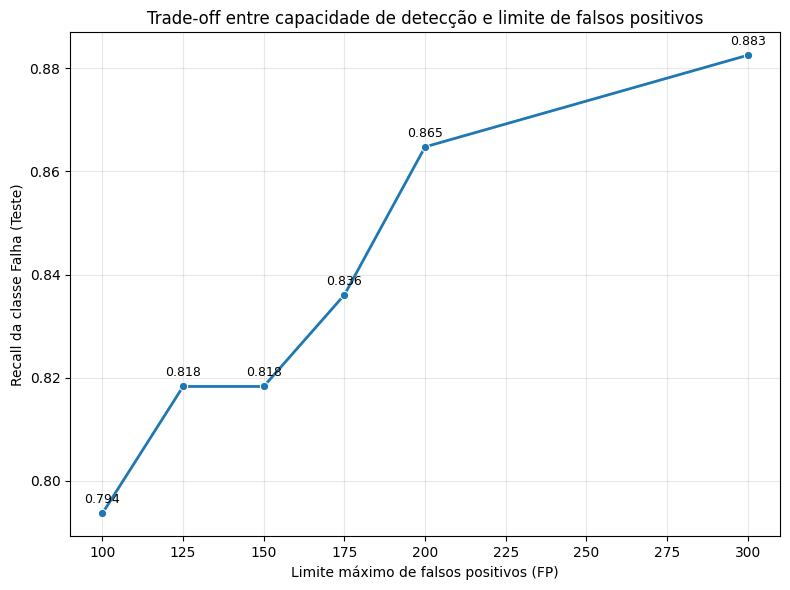

In [ ]:
df_plot = df_sweep.sort_values("fp_limit")

plt.figure(figsize=(8,6))

sns.lineplot(
    data=df_plot,
    x="fp_limit",
    y="test_recall_fault",
    marker="o",
    linewidth=2
)

plt.xlabel("Limite máximo de falsos positivos (FP)")
plt.ylabel("Recall da classe Falha (Teste)")
plt.title("Trade-off entre capacidade de detecção e limite de falsos positivos")

plt.grid(True, alpha=0.3)

for _, row in df_plot.iterrows():
    plt.text(
        row["fp_limit"],
        row["test_recall_fault"] + 0.002,
        f"{row['test_recall_fault']:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
proba_test = best_rf_detector.predict_proba(X_test)[:, 1]
y_test_pred = (proba_test >= 0.3).astype(int)

print("=== RESULTADO FINAL (TESTE) ===")
print(classification_report(y_test_bin, y_test_pred, digits=4))


=== RESULTADO FINAL (TESTE) ===
              precision    recall  f1-score   support

           0     0.9228    0.8107    0.8631      1268
           1     0.7291    0.8825    0.7985       732

    accuracy                         0.8370      2000
   macro avg     0.8260    0.8466    0.8308      2000
weighted avg     0.8519    0.8370    0.8395      2000



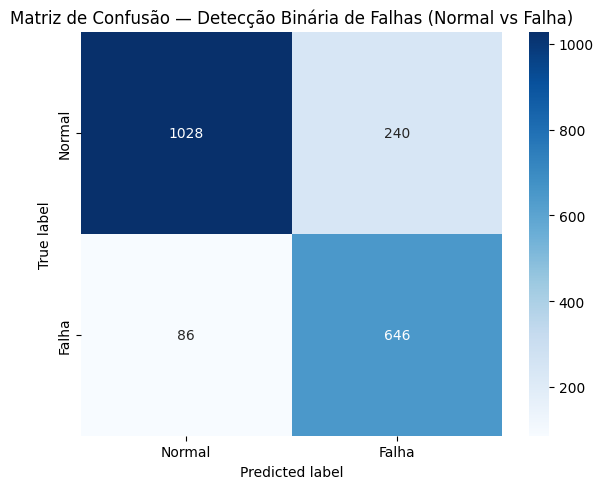

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, y_test_pred))

##### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

search.fit(X_train_faults, y_train_faults)

best_rf_faults = search.best_estimator_

print("\nMelhores parâmetros encontrados (Modelo 2 - falhas 1–7):")
print(search.best_params_)
print(f"Melhor score médio (CV) em f1_macro: {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



Melhores parâmetros encontrados (Modelo 2 - falhas 1–7):
{'class_weight': 'balanced', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 11, 'min_samples_split': 9, 'n_estimators': 388}
Melhor score médio (CV) em f1_macro: nan


In [ ]:
pred_test_faults = best_rf_faults.predict(X_test_faults_true)

print("\n=== MODELO 2 OTIMIZADO: Diagnóstico (Falhas 1–7) no TESTE (apenas falhas reais) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))



=== MODELO 2 OTIMIZADO: Diagnóstico (Falhas 1–7) no TESTE (apenas falhas reais) ===
              precision    recall  f1-score   support

           1     0.7900    0.7315    0.7596       108
           2     0.8036    0.8411    0.8219       107
           3     0.8636    0.8261    0.8444        92
           4     1.0000    1.0000    1.0000       100
           5     0.9496    0.9741    0.9617       116
           6     0.9633    1.0000    0.9813       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9112       732
   macro avg     0.9100    0.9104    0.9099       732
weighted avg     0.9099    0.9112    0.9102       732



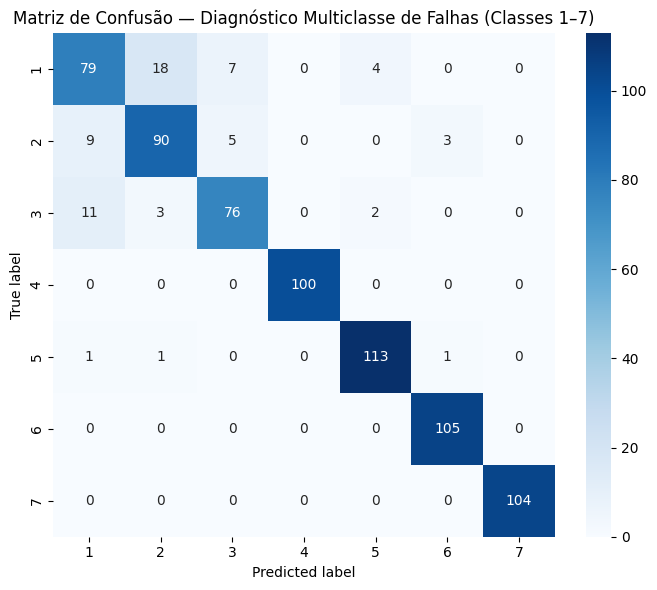

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults))

#####  3.Evaluation of the complete pipeline (simulating real-world usage) 2º Version

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
final_pred_multi_rf_thr = np.zeros(len(X_test), dtype=int)

idx_pred_fault_rf_thr = np.where(pred_bin_test == 1)[0]

if len(idx_pred_fault_rf_thr) > 0:
    pred_faults_main_rf_thr_0 = best_rf_faults.predict(X_test.iloc[idx_pred_fault_rf_thr])
    pred_faults_main_rf_thr = pred_faults_main_rf_thr_0 + 1

    mask_main_123_rf_thr = np.isin(pred_faults_main_rf_thr, [1, 2, 3])

    if mask_main_123_rf_thr.any():
        idx_123_rf_thr = idx_pred_fault_rf_thr[mask_main_123_rf_thr]
        pred_123_rf_thr = best_rf_123.predict(X_test.iloc[idx_123_rf_thr]) + 1
        pred_faults_main_rf_thr[mask_main_123_rf_thr] = pred_123_rf_thr

    final_pred_multi_rf_thr[idx_pred_fault_rf_thr] = pred_faults_main_rf_thr

print("\n=== PIPELINE COMPLETO RF (Config 4 melhorada) ===")
print(classification_report(y_test_multi, final_pred_multi_rf_thr, digits=4))

#####  3.Evaluation of the complete pipeline (simulating real-world usage) 1º Version

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
proba_test = best_rf_detector.predict_proba(X_test)[:, 1]
pred_bin_test = (proba_test >= 0.3).astype(int)

final_pred_multi = np.zeros(len(X_test), dtype=int)

idx_pred_fault = np.where(pred_bin_test == 1)[0]

if len(idx_pred_fault) > 0:
    final_pred_multi[idx_pred_fault] = best_rf_faults.predict(X_test.iloc[idx_pred_fault])

print("\n=== PIPELINE COMPLETO no TESTE (0 vs 1–7) ===")
print(classification_report(y_test_multi, final_pred_multi, digits=4))



=== PIPELINE COMPLETO no TESTE (0 vs 1–7) ===
              precision    recall  f1-score   support

           0     0.9228    0.8107    0.8631      1268
           1     0.2959    0.4630    0.3610       108
           2     0.5659    0.6822    0.6186       107
           3     0.5231    0.7391    0.6126        92
           4     1.0000    1.0000    1.0000       100
           5     0.7902    0.9741    0.8726       116
           6     0.9279    0.9810    0.9537       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.8195      2000
   macro avg     0.7532    0.8313    0.7852      2000
weighted avg     0.8519    0.8195    0.8307      2000



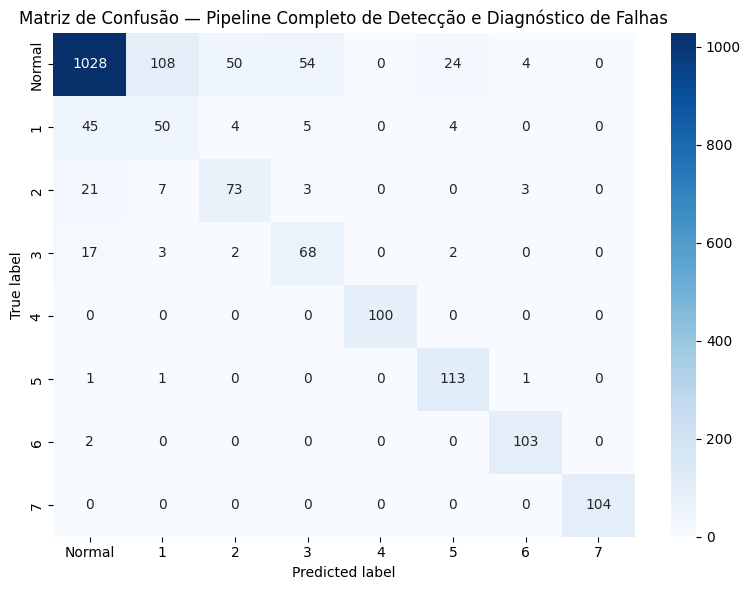

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi))

## XGBoost

### Baseline configuration

#### 1.Detection (Normal vs. Fault)

In [ ]:
recall_fault_scorer = make_scorer(recall_score, pos_label=1)
tscv = TimeSeriesSplit(n_splits=3)

neg = (y_train_bin == 0).sum()
pos = (y_train_bin == 1).sum()
scale_pos_weight = neg / max(pos, 1)

xgb_detector = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight
)

param_dist_detector = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.03, 0.25),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

search_detector = RandomizedSearchCV(
    estimator=xgb_detector,
    param_distributions=param_dist_detector,
    n_iter=30,
    scoring="balanced_accuracy",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_detector.fit(X_train, y_train_bin)

best_xgb_detector = search_detector.best_estimator_

print("\nMelhores parâmetros (Detector):")
print(search_detector.best_params_)
print(f"Melhor recall médio (CV) - Falha=1: {search_detector.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Melhores parâmetros (Detector):
{'colsample_bytree': np.float64(0.8469926038510867), 'gamma': np.float64(0.30582658024414044), 'learning_rate': np.float64(0.03176657630492935), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 674, 'reg_alpha': np.float64(0.6118528947223795), 'reg_lambda': np.float64(0.7789877213040837), 'subsample': np.float64(0.7168578594140873)}
Melhor recall médio (CV) - Falha=1: 0.8451


In [ ]:
pred_test_bin = best_xgb_detector.predict(X_test)

print("\n=== MODELO 1 OTIMIZADO: Detecção (0 vs 1) - XGBoost (Teste) ===")
print(classification_report(y_test_bin, pred_test_bin, digits=4))


=== MODELO 1 OTIMIZADO: Detecção (0 vs 1) - XGBoost (Teste) ===
              precision    recall  f1-score   support

           0     0.8920    0.9188    0.9052      1268
           1     0.8516    0.8074    0.8289       732

    accuracy                         0.8780      2000
   macro avg     0.8718    0.8631    0.8670      2000
weighted avg     0.8772    0.8780    0.8773      2000



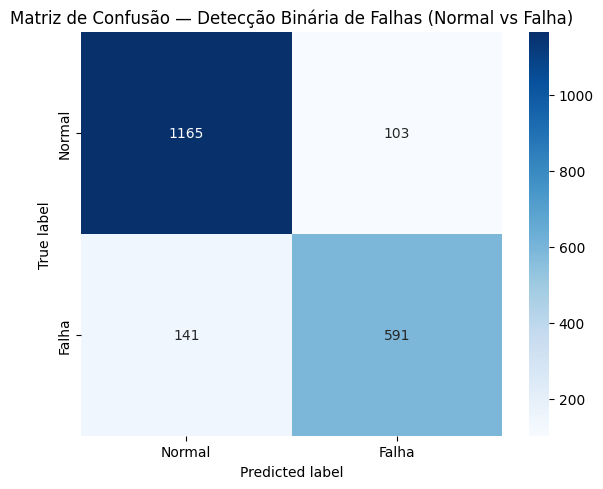

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, pred_test_bin))

#### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

y_train_faults_0 = (y_train_faults - 1).astype(int)
y_test_faults_0  = (y_test_faults_true - 1).astype(int)

xgb_faults = XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_dist_faults = {
    "n_estimators": randint(200, 900),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.03, 0.25),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

search_faults = RandomizedSearchCV(
    estimator=xgb_faults,
    param_distributions=param_dist_faults,
    n_iter=30,
    scoring="balanced_accuracy",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_faults.fit(X_train_faults, y_train_faults_0)

best_xgb_faults = search_faults.best_estimator_

print("\nMelhores parâmetros (Diagnóstico 1–7):")
print(search_faults.best_params_)
print(f"Melhor f1_macro médio (CV): {search_faults.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Melhores parâmetros (Diagnóstico 1–7):
{'colsample_bytree': np.float64(0.6353970008207678), 'gamma': np.float64(0.0979914312095726), 'learning_rate': np.float64(0.041306822227634515), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 252, 'reg_alpha': np.float64(0.5867511656638482), 'reg_lambda': np.float64(2.430510614528276), 'subsample': np.float64(0.8428136990746738)}
Melhor f1_macro médio (CV): 0.9285


In [ ]:
proba_test_faults = best_xgb_faults.predict_proba(X_test_faults_true)
pred_test_faults_0 = np.argmax(proba_test_faults, axis=1)
pred_test_faults = pred_test_faults_0 + 1

print("\n=== MODELO 2 OTIMIZADO: Diagnóstico (1–7) - XGBoost (Teste, apenas falhas reais) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))


=== MODELO 2 OTIMIZADO: Diagnóstico (1–7) - XGBoost (Teste, apenas falhas reais) ===
              precision    recall  f1-score   support

           1     0.8370    0.7130    0.7700       108
           2     0.7869    0.8972    0.8384       107
           3     0.8571    0.8478    0.8525        92
           4     1.0000    1.0000    1.0000       100
           5     0.9825    0.9655    0.9739       116
           6     0.9541    0.9905    0.9720       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9167       732
   macro avg     0.9168    0.9163    0.9153       732
weighted avg     0.9175    0.9167    0.9157       732



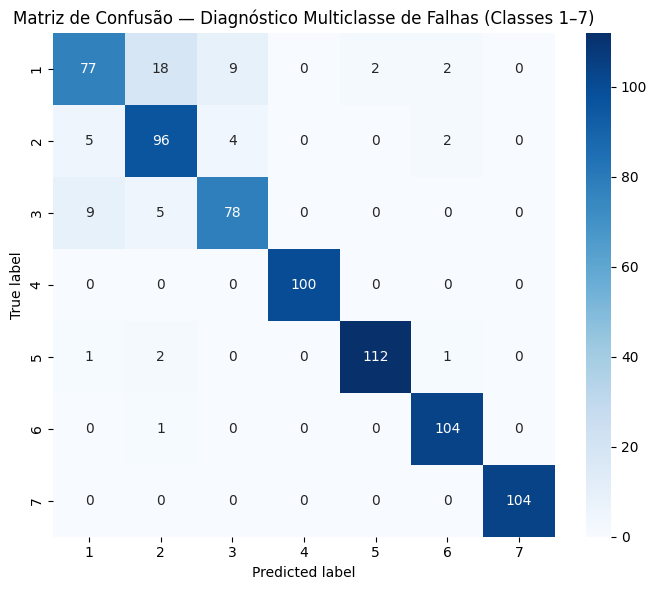

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults))

####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
final_pred_multi = np.zeros(len(X_test), dtype=int)

idx_pred_fault = np.where(pred_test_bin == 1)[0]

if len(idx_pred_fault) > 0:
    proba_pipeline_faults = best_xgb_faults.predict_proba(X_test.iloc[idx_pred_fault])
    pred_pipeline_faults_0 = np.argmax(proba_pipeline_faults, axis=1)
    final_pred_multi[idx_pred_fault] = pred_pipeline_faults_0 + 1

print("\n=== PIPELINE COMPLETO (0 vs 1–7) - XGBoost (Teste) ===")
print(classification_report(y_test_multi, final_pred_multi, digits=4))


=== PIPELINE COMPLETO (0 vs 1–7) - XGBoost (Teste) ===
              precision    recall  f1-score   support

           0     0.8920    0.9188    0.9052      1268
           1     0.4493    0.2870    0.3503       108
           2     0.6633    0.6075    0.6341       107
           3     0.6531    0.6957    0.6737        92
           4     1.0000    1.0000    1.0000       100
           5     0.9328    0.9569    0.9447       116
           6     0.9252    0.9429    0.9340       105
           7     1.0000    0.9904    0.9952       104

    accuracy                         0.8690      2000
   macro avg     0.8145    0.7999    0.8046      2000
weighted avg     0.8600    0.8690    0.8633      2000



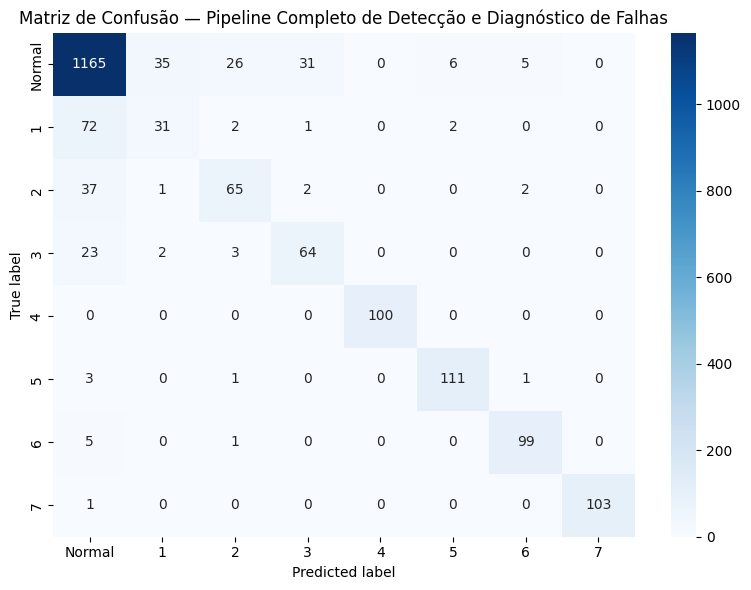

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi))

### scoring="roc_auc" configuration

#### 1.Detection (Normal vs. Fault)

In [ ]:
recall_fault_scorer = make_scorer(recall_score, pos_label=1)
tscv = TimeSeriesSplit(n_splits=3)

neg = (y_train_bin == 0).sum()
pos = (y_train_bin == 1).sum()
scale_pos_weight = neg / max(pos, 1)

xgb_detector = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight
)

param_dist_detector = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.03, 0.25),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

search_detector = RandomizedSearchCV(
    estimator=xgb_detector,
    param_distributions=param_dist_detector,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_detector.fit(X_train, y_train_bin)

best_xgb_detector = search_detector.best_estimator_

print("\nMelhores parâmetros (Detector):")
print(search_detector.best_params_)
print(f"Melhor recall médio (CV) - Falha=1: {search_detector.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Melhores parâmetros (Detector):
{'colsample_bytree': np.float64(0.8469926038510867), 'gamma': np.float64(0.30582658024414044), 'learning_rate': np.float64(0.03176657630492935), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 674, 'reg_alpha': np.float64(0.6118528947223795), 'reg_lambda': np.float64(0.7789877213040837), 'subsample': np.float64(0.7168578594140873)}
Melhor recall médio (CV) - Falha=1: 0.9140


In [ ]:
pred_test_bin = best_xgb_detector.predict(X_test)

print("\n=== MODELO 1 OTIMIZADO: Detecção (0 vs 1) - XGBoost (Teste) ===")
print(classification_report(y_test_bin, pred_test_bin, digits=4))


=== MODELO 1 OTIMIZADO: Detecção (0 vs 1) - XGBoost (Teste) ===
              precision    recall  f1-score   support

           0     0.8920    0.9188    0.9052      1268
           1     0.8516    0.8074    0.8289       732

    accuracy                         0.8780      2000
   macro avg     0.8718    0.8631    0.8670      2000
weighted avg     0.8772    0.8780    0.8773      2000



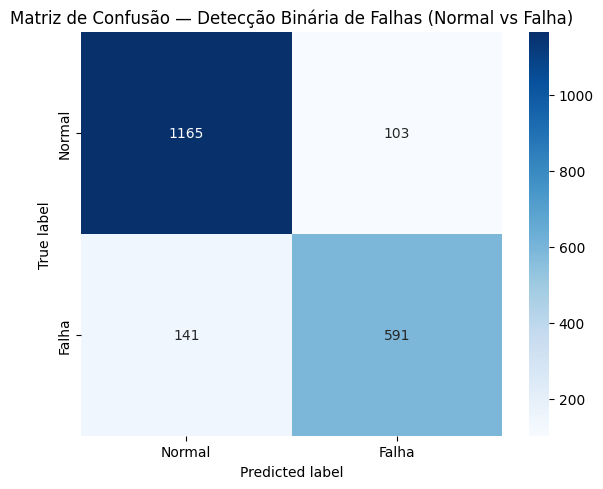

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, pred_test_bin))

#### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

y_train_faults_0 = (y_train_faults - 1).astype(int)
y_test_faults_0  = (y_test_faults_true - 1).astype(int)

xgb_faults = XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_dist_faults = {
    "n_estimators": randint(200, 900),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.03, 0.25),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

search_faults = RandomizedSearchCV(
    estimator=xgb_faults,
    param_distributions=param_dist_faults,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_faults.fit(X_train_faults, y_train_faults_0)

best_xgb_faults = search_faults.best_estimator_

print("\nMelhores parâmetros (Diagnóstico 1–7):")
print(search_faults.best_params_)
print(f"Melhor f1_macro médio (CV): {search_faults.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



Melhores parâmetros (Diagnóstico 1–7):
{'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.21299848545285127), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 814, 'reg_alpha': np.float64(0.44583275285359114), 'reg_lambda': np.float64(0.6999498316360058), 'subsample': np.float64(0.7836995567863468)}
Melhor f1_macro médio (CV): nan


In [ ]:
proba_test_faults = best_xgb_faults.predict_proba(X_test_faults_true)
pred_test_faults_0 = np.argmax(proba_test_faults, axis=1)
pred_test_faults = pred_test_faults_0 + 1

print("\n=== MODELO 2 OTIMIZADO: Diagnóstico (1–7) - XGBoost (Teste, apenas falhas reais) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))


=== MODELO 2 OTIMIZADO: Diagnóstico (1–7) - XGBoost (Teste, apenas falhas reais) ===
              precision    recall  f1-score   support

           1     0.8222    0.6852    0.7475       108
           2     0.7833    0.8785    0.8282       107
           3     0.8387    0.8478    0.8432        92
           4     1.0000    1.0000    1.0000       100
           5     0.9825    0.9655    0.9739       116
           6     0.9459    1.0000    0.9722       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9112       732
   macro avg     0.9104    0.9110    0.9093       732
weighted avg     0.9113    0.9112    0.9098       732



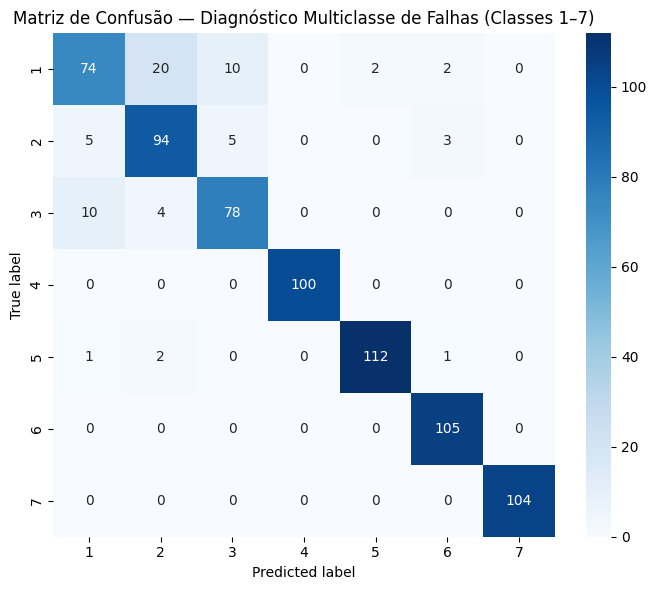

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults))

####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
final_pred_multi = np.zeros(len(X_test), dtype=int)

idx_pred_fault = np.where(pred_test_bin == 1)[0]

if len(idx_pred_fault) > 0:
    proba_pipeline_faults = best_xgb_faults.predict_proba(X_test.iloc[idx_pred_fault])
    pred_pipeline_faults_0 = np.argmax(proba_pipeline_faults, axis=1)
    final_pred_multi[idx_pred_fault] = pred_pipeline_faults_0 + 1

print("\n=== PIPELINE COMPLETO (0 vs 1–7) - XGBoost (Teste) ===")
print(classification_report(y_test_multi, final_pred_multi, digits=4))


=== PIPELINE COMPLETO (0 vs 1–7) - XGBoost (Teste) ===
              precision    recall  f1-score   support

           0     0.8920    0.9188    0.9052      1268
           1     0.4545    0.2778    0.3448       108
           2     0.6667    0.5981    0.6305       107
           3     0.6667    0.7174    0.6911        92
           4     1.0000    1.0000    1.0000       100
           5     0.9250    0.9569    0.9407       116
           6     0.9091    0.9524    0.9302       105
           7     1.0000    0.9904    0.9952       104

    accuracy                         0.8695      2000
   macro avg     0.8143    0.8015    0.8047      2000
weighted avg     0.8598    0.8695    0.8632      2000



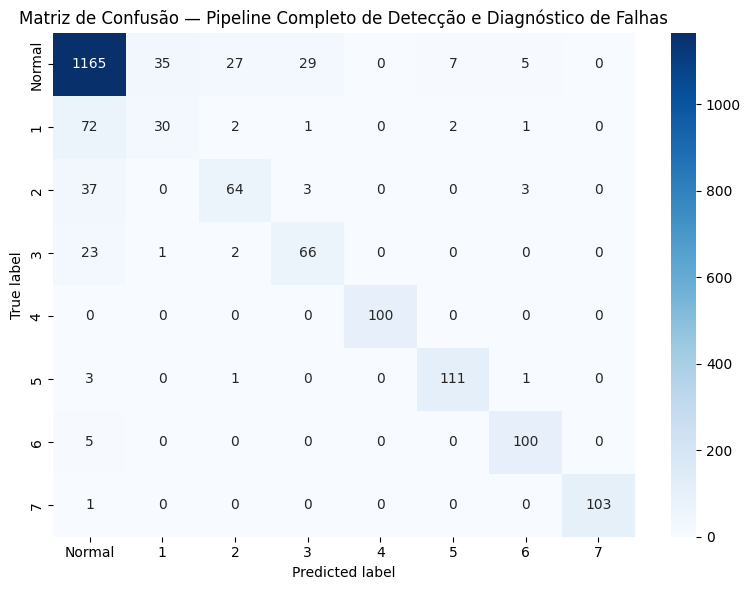

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi))

### recall_fault_scorer configuration

#### 1.Detection (Normal vs. Fault)

In [ ]:
recall_fault_scorer = make_scorer(recall_score, pos_label=1)
tscv = TimeSeriesSplit(n_splits=3)

neg = (y_train_bin == 0).sum()
pos = (y_train_bin == 1).sum()
scale_pos_weight = neg / max(pos, 1)

xgb_detector = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight
)

param_dist_detector = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.03, 0.25),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

search = RandomizedSearchCV(
    estimator=xgb_detector,
    param_distributions=param_dist_detector,
    n_iter=30,
    scoring=recall_fault_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train_bin)

best_xgb_detector = search.best_estimator_

print("\nMelhores parâmetros (Detector):")
print(search.best_params_)
print(f"Melhor recall médio (CV) - Falha=1: {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Melhores parâmetros (Detector):
{'colsample_bytree': np.float64(0.8469926038510867), 'gamma': np.float64(0.30582658024414044), 'learning_rate': np.float64(0.03176657630492935), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 674, 'reg_alpha': np.float64(0.6118528947223795), 'reg_lambda': np.float64(0.7789877213040837), 'subsample': np.float64(0.7168578594140873)}
Melhor recall médio (CV) - Falha=1: 0.7684


In [ ]:
pred_test_bin = best_xgb_detector.predict(X_test)

print("\n=== MODELO 1 OTIMIZADO: Detecção (0 vs 1) - XGBoost (Teste) ===")
print(classification_report(y_test_bin, pred_test_bin, digits=4))


=== MODELO 1 OTIMIZADO: Detecção (0 vs 1) - XGBoost (Teste) ===
              precision    recall  f1-score   support

           0     0.8920    0.9188    0.9052      1268
           1     0.8516    0.8074    0.8289       732

    accuracy                         0.8780      2000
   macro avg     0.8718    0.8631    0.8670      2000
weighted avg     0.8772    0.8780    0.8773      2000



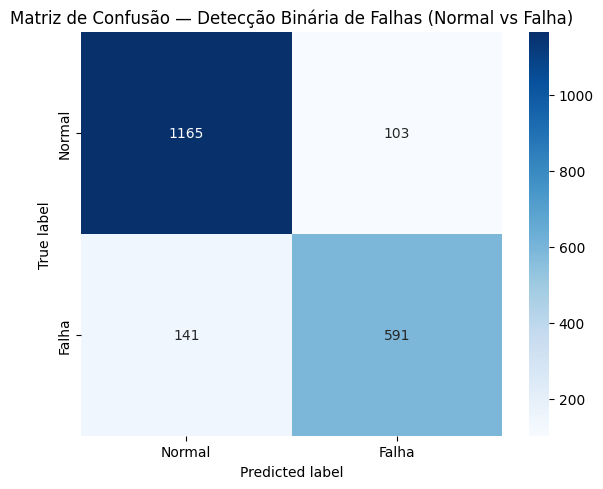

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, pred_test_bin))

Using only the top 90% of features ranked by importance to see the result

In [ ]:
detector_importance = top_features_from_permutation(
    model=best_xgb_detector,
    X=X_test,
    y=y_test_bin,
    scoring="recall"
)

print(detector_importance.head(20))

                   feature  importance_mean  importance_std
0             Air_Pressure     1.150273e-01        0.004604
1             Oil_Pressure     8.101093e-02        0.009022
2                Fuel_Flow     3.866120e-02        0.005534
3       Cylinder3_Pressure     2.827869e-02        0.004734
4   Cylinder2_Exhaust_Temp     2.459016e-02        0.004320
5       Cylinder4_Pressure     2.049180e-02        0.002866
6       Cylinder2_Pressure     1.953552e-02        0.002803
7   Cylinder3_Exhaust_Temp     1.803279e-02        0.002428
8       Cylinder1_Pressure     1.789617e-02        0.003426
9   Cylinder1_Exhaust_Temp     1.762295e-02        0.002830
10  Cylinder4_Exhaust_Temp     1.707650e-02        0.003009
11                Oil_Temp     1.530055e-02        0.002719
12            Ambient_Temp     1.775956e-03        0.002736
13             Vibration_Z    -3.330669e-17        0.002663
14             Engine_Load    -1.366120e-04        0.001289
15             Vibration_Y    -8.196721e

In [ ]:
n_det = int(len(detector_importance) * 0.9)

top_features_detector = detector_importance["feature"].iloc[:n_det].tolist()

print("Features selecionadas (Detector):")
print(top_features_detector)

Features selecionadas (Detector):
['Air_Pressure', 'Oil_Pressure', 'Fuel_Flow', 'Cylinder3_Pressure', 'Cylinder2_Exhaust_Temp', 'Cylinder4_Pressure', 'Cylinder2_Pressure', 'Cylinder3_Exhaust_Temp', 'Cylinder1_Pressure', 'Cylinder1_Exhaust_Temp', 'Cylinder4_Exhaust_Temp', 'Oil_Temp', 'Ambient_Temp', 'Vibration_Z', 'Engine_Load', 'Vibration_Y']


In [ ]:
search.fit(X_train[top_features_detector], y_train_bin)
best_xgb_detector_top = search.best_estimator_
pred_test_bin_top = best_xgb_detector_top.predict(X_test[top_features_detector])

print("\n=== MODELO 1 OTIMIZADO: Detecção (0 vs 1) - XGBoost (Teste) ===")
print(classification_report(y_test_bin, pred_test_bin_top, digits=4))

Fitting 3 folds for each of 30 candidates, totalling 90 fits

=== MODELO 1 OTIMIZADO: Detecção (0 vs 1) - XGBoost (Teste) ===
              precision    recall  f1-score   support

           0     0.8897    0.9156    0.9024      1268
           1     0.8460    0.8033    0.8241       732

    accuracy                         0.8745      2000
   macro avg     0.8678    0.8594    0.8633      2000
weighted avg     0.8737    0.8745    0.8738      2000



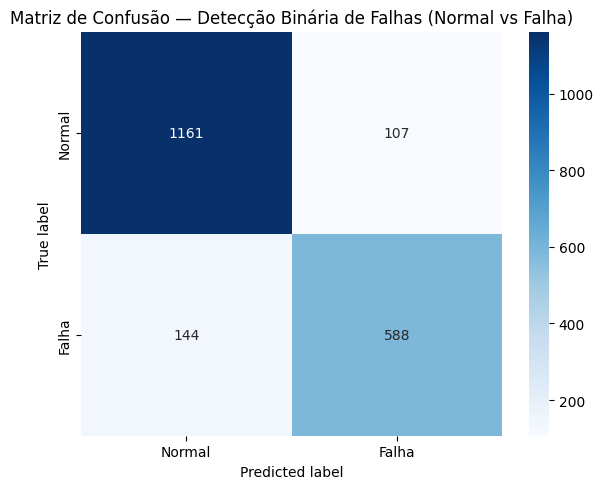

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, pred_test_bin_top))

#### 2º Version

##### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

y_train_faults_0 = (y_train_faults - 1).astype(int)
y_test_faults_0  = (y_test_faults_true - 1).astype(int)

sample_weight_xgb_faults = build_sample_weights_multiclass(
    y_train_faults_0.values,
    boost_labels=(0, 1, 2),
    boost_factor=2.0
)

xgb_faults = XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_dist_faults_xgb = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.03, 0.25),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

search_faults_xgb = RandomizedSearchCV(
    estimator=xgb_faults,
    param_distributions=param_dist_faults_xgb,
    n_iter=30,
    scoring=multiclass_focus_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_faults_xgb.fit(
    X_train_faults,
    y_train_faults_0,
    sample_weight=sample_weight_xgb_faults
)

best_xgb_faults = search_faults_xgb.best_estimator_

print("\n[XGB Multiclasse] Melhores parâmetros:")
print(search_faults_xgb.best_params_)
print(f"[XGB Multiclasse] Melhor score médio (CV): {search_faults_xgb.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

[XGB Multiclasse] Melhores parâmetros:
{'colsample_bytree': np.float64(0.8493192507310232), 'gamma': np.float64(0.1654490124263246), 'learning_rate': np.float64(0.04588958757150591), 'max_depth': 9, 'min_child_weight': 8, 'n_estimators': 298, 'reg_alpha': np.float64(0.5912977877077271), 'reg_lambda': np.float64(1.0494435859801283), 'subsample': np.float64(0.8244973703390804)}
[XGB Multiclasse] Melhor score médio (CV): 0.8795


In [ ]:
proba_test_faults_xgb = best_xgb_faults.predict_proba(X_test_faults_true)
pred_test_faults_xgb_0 = np.argmax(proba_test_faults_xgb, axis=1)
pred_test_faults_xgb = pred_test_faults_xgb_0 + 1

print("\n=== XGB DIAGNÓSTICO (Teste, apenas falhas reais) ===")
print(classification_report(y_test_faults_true, pred_test_faults_xgb, digits=4))


=== XGB DIAGNÓSTICO (Teste, apenas falhas reais) ===
              precision    recall  f1-score   support

           1     0.8478    0.7222    0.7800       108
           2     0.8034    0.8785    0.8393       107
           3     0.8542    0.8913    0.8723        92
           4     1.0000    1.0000    1.0000       100
           5     0.9825    0.9655    0.9739       116
           6     0.9545    1.0000    0.9767       105
           7     1.0000    0.9904    0.9952       104

    accuracy                         0.9208       732
   macro avg     0.9203    0.9211    0.9196       732
weighted avg     0.9212    0.9208    0.9198       732



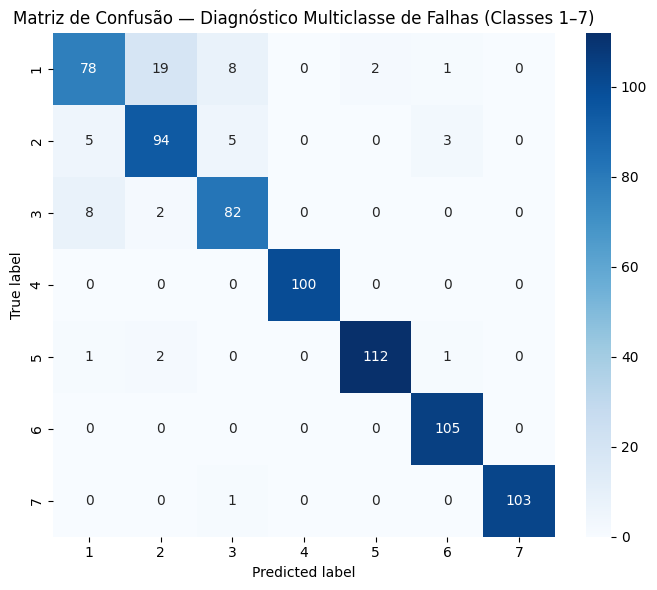

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults_xgb))

SPECIALIST FOR CLASSES 1, 2, AND 3

In [ ]:
mask_123_train = y_train_faults.isin([1, 2, 3])
mask_123_test  = y_test_faults_true.isin([1, 2, 3])

X_train_123_xgb = X_train_faults.loc[mask_123_train]
y_train_123_xgb = y_train_faults.loc[mask_123_train].astype(int) - 1  # 1,2,3 -> 0,1,2

X_test_123_xgb = X_test_faults_true.loc[mask_123_test]
y_test_123_xgb = y_test_faults_true.loc[mask_123_test].astype(int) - 1

xgb_123 = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_dist_123_xgb = {
    "n_estimators": randint(200, 600),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.03, 0.20),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 8),
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

search_123_xgb = RandomizedSearchCV(
    estimator=xgb_123,
    param_distributions=param_dist_123_xgb,
    n_iter=20,
    scoring=make_scorer(recall_score, average="macro", zero_division=0),
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_123_xgb.fit(X_train_123_xgb, y_train_123_xgb)

best_xgb_123 = search_123_xgb.best_estimator_

print("\n[XGB Especialista 1-3] Melhores parâmetros:")
print(search_123_xgb.best_params_)
print(f"[XGB Especialista 1-3] Melhor recall macro (CV): {search_123_xgb.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

[XGB Especialista 1-3] Melhores parâmetros:
{'colsample_bytree': np.float64(0.9895022075365837), 'gamma': np.float64(0.11638567021515211), 'learning_rate': np.float64(0.048121286906564156), 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 254, 'reg_alpha': np.float64(0.9832308858067882), 'reg_lambda': np.float64(1.4335257864959599), 'subsample': np.float64(0.9439761626945282)}
[XGB Especialista 1-3] Melhor recall macro (CV): 0.8642


#####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
final_pred_multi_xgb = np.zeros(len(X_test), dtype=int)

pred_bin_test_xgb = best_xgb_detector.predict(X_test)

idx_pred_fault_xgb = np.where(pred_bin_test_xgb == 1)[0]

if len(idx_pred_fault_xgb) > 0:
    proba_pipeline_faults_xgb = best_xgb_faults.predict_proba(X_test.iloc[idx_pred_fault_xgb])
    pred_faults_main_xgb_0 = np.argmax(proba_pipeline_faults_xgb, axis=1)
    pred_faults_main_xgb = pred_faults_main_xgb_0 + 1

     mask_main_123_xgb = np.isin(pred_faults_main_xgb, [1, 2, 3])

    if mask_main_123_xgb.any():
        idx_123_xgb = idx_pred_fault_xgb[mask_main_123_xgb]
        proba_123_xgb = best_xgb_123.predict_proba(X_test.iloc[idx_123_xgb])
        pred_123_xgb = np.argmax(proba_123_xgb, axis=1) + 1
        pred_faults_main_xgb[mask_main_123_xgb] = pred_123_xgb

    final_pred_multi_xgb[idx_pred_fault_xgb] = pred_faults_main_xgb

print("\n=== PIPELINE COMPLETO XGB (Config 3 melhorada) ===")
print(classification_report(y_test_multi, final_pred_multi_xgb, digits=4))


=== PIPELINE COMPLETO XGB (Config 3 melhorada) ===
              precision    recall  f1-score   support

           0     0.8920    0.9188    0.9052      1268
           1     0.4627    0.2870    0.3543       108
           2     0.6364    0.5888    0.6117       107
           3     0.6531    0.6957    0.6737        92
           4     1.0000    1.0000    1.0000       100
           5     0.9328    0.9569    0.9447       116
           6     0.9174    0.9524    0.9346       105
           7     1.0000    0.9808    0.9903       104

    accuracy                         0.8680      2000
   macro avg     0.8118    0.7975    0.8018      2000
weighted avg     0.8589    0.8680    0.8621      2000



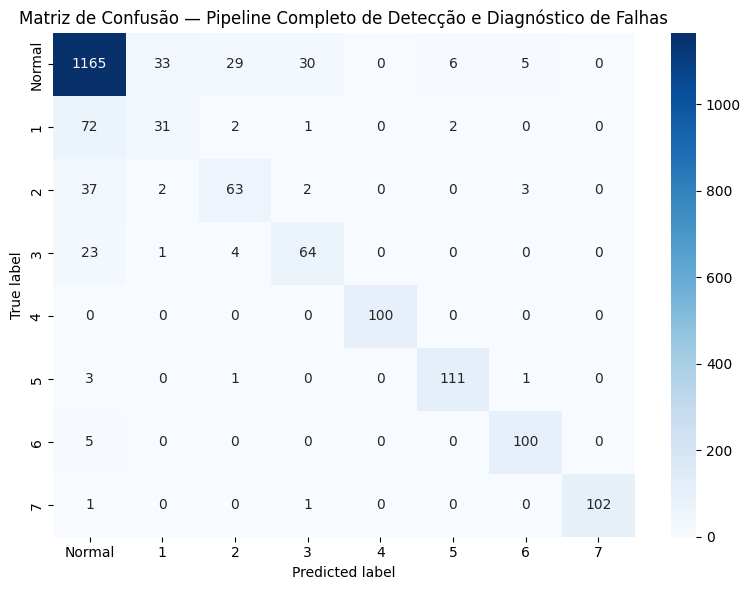

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi_xgb))

#### 1º Version

##### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

y_train_faults_0 = (y_train_faults - 1).astype(int)
y_test_faults_0  = (y_test_faults_true - 1).astype(int)

search.fit(X_train_faults, y_train_faults_0)

best_xgb_faults = search.best_estimator_

print("\nMelhores parâmetros (Diagnóstico 1–7):")
print(search.best_params_)
print(f"Melhor f1_macro médio (CV): {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:28:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Melhores parâmetros (Diagnóstico 1–7):
{'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.21299848545285127), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 321, 'reg_alpha': np.float64(0.15599452033620265), 'reg_lambda': np.float64(0.6161672243363989), 'subsample': np.float64(0.9464704583099741)}
Melhor f1_macro médio (CV): nan


In [ ]:
proba_test_faults = best_xgb_faults.predict_proba(X_test_faults_true)
pred_test_faults_0 = np.argmax(proba_test_faults, axis=1)
pred_test_faults = pred_test_faults_0 + 1

print("\n=== MODELO 2 OTIMIZADO: Diagnóstico (1–7) - XGBoost (Teste, apenas falhas reais) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))


=== MODELO 2 OTIMIZADO: Diagnóstico (1–7) - XGBoost (Teste, apenas falhas reais) ===
              precision    recall  f1-score   support

           1     0.8316    0.7315    0.7783       108
           2     0.8230    0.8692    0.8455       107
           3     0.8438    0.8804    0.8617        92
           4     1.0000    1.0000    1.0000       100
           5     0.9825    0.9655    0.9739       116
           6     0.9545    1.0000    0.9767       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9208       732
   macro avg     0.9193    0.9209    0.9194       732
weighted avg     0.9203    0.9208    0.9199       732



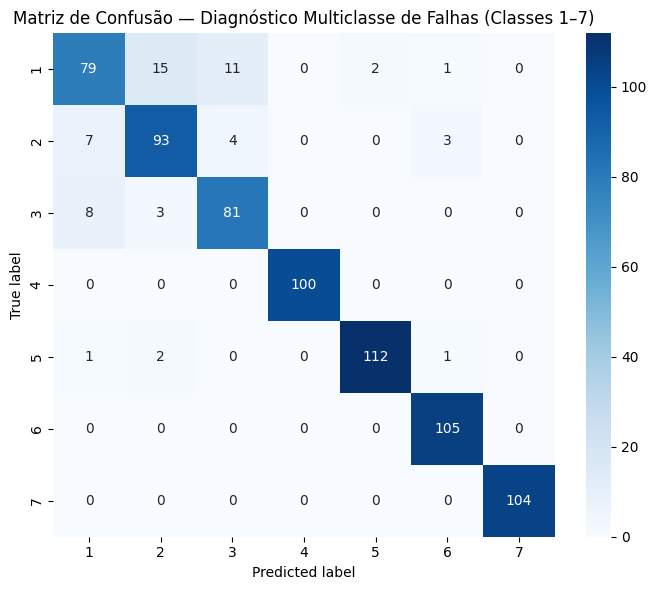

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults))

###### Using only the top 90% of features ranked by importance to see the result

In [ ]:
faults_importance = top_features_from_permutation(
    model=best_xgb_faults,
    X=X_test_faults_true,
    y=y_test_faults_0,
    scoring="f1_macro"
)

print(faults_importance.head(20))

                   feature  importance_mean  importance_std
0              Vibration_Z         0.203558        0.008500
1             Air_Pressure         0.179743        0.006430
2             Oil_Pressure         0.127391        0.011019
3              Vibration_Y         0.104616        0.008888
4                Fuel_Flow         0.042311        0.009839
5   Cylinder4_Exhaust_Temp         0.035827        0.004226
6   Cylinder3_Exhaust_Temp         0.035697        0.006618
7   Cylinder2_Exhaust_Temp         0.033846        0.002954
8   Cylinder1_Exhaust_Temp         0.029043        0.004904
9              Vibration_X         0.025948        0.004660
10      Cylinder1_Pressure         0.025311        0.005165
11      Cylinder4_Pressure         0.023663        0.003220
12                Oil_Temp         0.023293        0.005415
13      Cylinder3_Pressure         0.020669        0.004099
14      Cylinder2_Pressure         0.019657        0.003014
15               Shaft_RPM         0.002

In [ ]:
n_faults = int(len(faults_importance) * 0.9)

top_features_faults = faults_importance["feature"].iloc[:n_faults].tolist()

print("Features selecionadas (Diagnóstico):")
print(top_features_faults)

Features selecionadas (Diagnóstico):
['Vibration_Z', 'Air_Pressure', 'Oil_Pressure', 'Vibration_Y', 'Fuel_Flow', 'Cylinder4_Exhaust_Temp', 'Cylinder3_Exhaust_Temp', 'Cylinder2_Exhaust_Temp', 'Cylinder1_Exhaust_Temp', 'Vibration_X', 'Cylinder1_Pressure', 'Cylinder4_Pressure', 'Oil_Temp', 'Cylinder3_Pressure', 'Cylinder2_Pressure', 'Shaft_RPM']


In [ ]:
search.fit(X_train_faults[top_features_faults], y_train_faults_0)
best_xgb_faults_top = search.best_estimator_
proba_test_faults = best_xgb_faults_top.predict_proba(X_test_faults_true[top_features_faults])
pred_test_faults_0 = np.argmax(proba_test_faults, axis=1)
pred_test_faults_top = pred_test_faults_0 + 1

print("\n=== MODELO 2 OTIMIZADO: Diagnóstico (1–7) - XGBoost (Teste, apenas falhas reais) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:30:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== MODELO 2 OTIMIZADO: Diagnóstico (1–7) - XGBoost (Teste, apenas falhas reais) ===
              precision    recall  f1-score   support

           1     0.8316    0.7315    0.7783       108
           2     0.8230    0.8692    0.8455       107
           3     0.8438    0.8804    0.8617        92
           4     1.0000    1.0000    1.0000       100
           5     0.9825    0.9655    0.9739       116
           6     0.9545    1.0000    0.9767       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9208       732
   macro avg     0.9193    0.9209    0.9194       732
weighted avg     0.9203    0.9208    0.9199       732



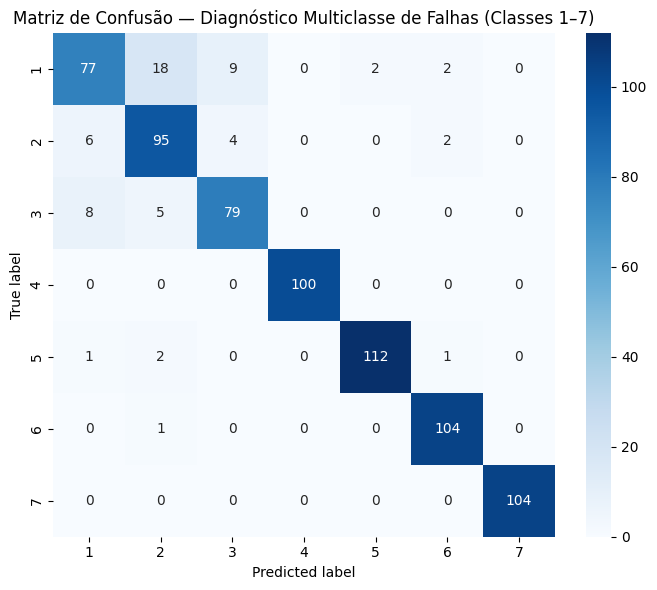

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults_top))

##### AUXILIARY FUNCTIONS

In [ ]:
def run_complete_pipeline(detector_model, faults_model,
                          X_train_bin, y_train_bin,
                          X_train_faults, y_train_faults_0,
                          X_test_bin, X_test_faults,
                          y_test_multi):
    detector_model.fit(X_train_bin, y_train_bin)
    faults_model.fit(X_train_faults, y_train_faults_0)

    pred_bin_test = detector_model.predict(X_test_bin)

    final_pred_multi = np.zeros(len(X_test_bin), dtype=int)
    idx_pred_fault = np.where(pred_bin_test == 1)[0]

    if len(idx_pred_fault) > 0:
        proba_pipeline_faults = faults_model.predict_proba(X_test_faults.iloc[idx_pred_fault])
        pred_pipeline_faults_0 = np.argmax(proba_pipeline_faults, axis=1)
        final_pred_multi[idx_pred_fault] = pred_pipeline_faults_0 + 1

    report = classification_report(y_test_multi, final_pred_multi, output_dict=True, zero_division=0)

    return {
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "recall_1": report["1"]["recall"],
        "recall_2": report["2"]["recall"],
        "recall_3": report["3"]["recall"],
    }

In [ ]:
fractions = [1.0, 0.9, 0.8, 0.7, 0.6]

results_feature_selection = []

for frac in fractions:
    n_det = max(1, int(len(detector_importance) * frac))
    selected_detector_features = detector_importance["feature"].iloc[:n_det].tolist()

    n_faults = max(1, int(len(faults_importance) * frac))
    selected_faults_features = faults_importance["feature"].iloc[:n_faults].tolist()

    detector_model_fs = clone(best_xgb_detector)
    faults_model_fs = clone(best_xgb_faults)

    metrics = run_complete_pipeline(
        detector_model=detector_model_fs,
        faults_model=faults_model_fs,
        X_train_bin=X_train[selected_detector_features],
        y_train_bin=y_train_bin,
        X_train_faults=X_train_faults[selected_faults_features],
        y_train_faults_0=y_train_faults_0,
        X_test_bin=X_test[selected_detector_features],
        X_test_faults=X_test[selected_faults_features],
        y_test_multi=y_test_multi
    )

    results_feature_selection.append({
        "fraction": frac,
        "n_detector_features": len(selected_detector_features),
        "n_faults_features": len(selected_faults_features),
        **metrics
    })

df_feature_selection = pd.DataFrame(results_feature_selection)
print(df_feature_selection.sort_values(["recall_1", "recall_2", "recall_3"], ascending=False))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:03:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:03:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:03:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:03:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200:

   fraction  n_detector_features  n_faults_features  accuracy  macro_f1  \
2       0.8                   14                 14    0.8105  0.683448   
4       0.6                   10                 10    0.7800  0.638839   
3       0.7                   12                 12    0.7990  0.659645   
1       0.9                   16                 16    0.8680  0.805340   
0       1.0                   18                 18    0.8685  0.803037   

   recall_1  recall_2  recall_3  
2  0.342593  0.532710  0.739130  
4  0.333333  0.392523  0.543478  
3  0.296296  0.411215  0.771739  
1  0.287037  0.598131  0.706522  
0  0.277778  0.598131  0.695652  


#####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
final_pred_multi = np.zeros(len(X_test), dtype=int)

idx_pred_fault = np.where(pred_test_bin == 1)[0]

if len(idx_pred_fault) > 0:
    proba_pipeline_faults = best_xgb_faults.predict_proba(X_test.iloc[idx_pred_fault])
    pred_pipeline_faults_0 = np.argmax(proba_pipeline_faults, axis=1)
    final_pred_multi[idx_pred_fault] = pred_pipeline_faults_0 + 1

print("\n=== PIPELINE COMPLETO (0 vs 1–7) - XGBoost (Teste) ===")
print(classification_report(y_test_multi, final_pred_multi, digits=4))


=== PIPELINE COMPLETO (0 vs 1–7) - XGBoost (Teste) ===
              precision    recall  f1-score   support

           0     0.8920    0.9188    0.9052      1268
           1     0.4545    0.2778    0.3448       108
           2     0.6842    0.6075    0.6436       107
           3     0.6505    0.7283    0.6872        92
           4     1.0000    1.0000    1.0000       100
           5     0.9328    0.9569    0.9447       116
           6     0.9259    0.9524    0.9390       105
           7     1.0000    0.9904    0.9952       104

    accuracy                         0.8705      2000
   macro avg     0.8175    0.8040    0.8074      2000
weighted avg     0.8613    0.8705    0.8644      2000



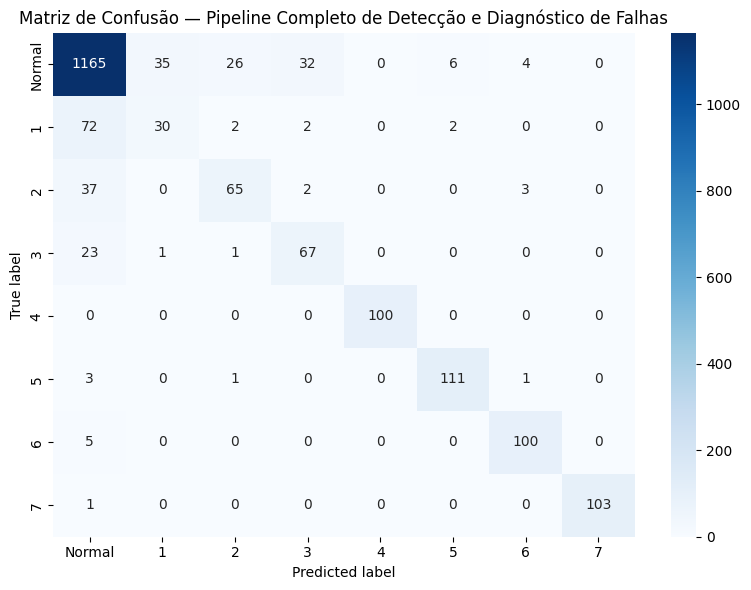

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi))

#####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is
*   Using only the top 90% of features ranked by importance to see the result



In [ ]:
final_pred_multi_top = np.zeros(len(X_test), dtype=int)

pred_bin_test_top = best_xgb_detector_top.predict(X_test[top_features_detector])

idx_pred_fault_top = np.where(pred_bin_test_top == 1)[0]

if len(idx_pred_fault_top) > 0:
    proba_pipeline_faults_top = best_xgb_faults_top.predict_proba(
        X_test[top_features_faults].iloc[idx_pred_fault_top]
    )
    pred_pipeline_faults_top_0 = np.argmax(proba_pipeline_faults_top, axis=1)
    final_pred_multi_top[idx_pred_fault_top] = pred_pipeline_faults_top_0 + 1

print("\n=== PIPELINE COMPLETO (0 vs 1–7) - XGBoost (Teste, top 90% features) ===")
print(classification_report(y_test_multi, final_pred_multi_top, digits=4))


=== PIPELINE COMPLETO (0 vs 1–7) - XGBoost (Teste, top 90% features) ===
              precision    recall  f1-score   support

           0     0.8897    0.9156    0.9024      1268
           1     0.4265    0.2685    0.3295       108
           2     0.6600    0.6168    0.6377       107
           3     0.6531    0.6957    0.6737        92
           4     1.0000    1.0000    1.0000       100
           5     0.9407    0.9569    0.9487       116
           6     0.9259    0.9524    0.9390       105
           7     1.0000    0.9904    0.9952       104

    accuracy                         0.8670      2000
   macro avg     0.8120    0.7995    0.8033      2000
weighted avg     0.8576    0.8670    0.8611      2000



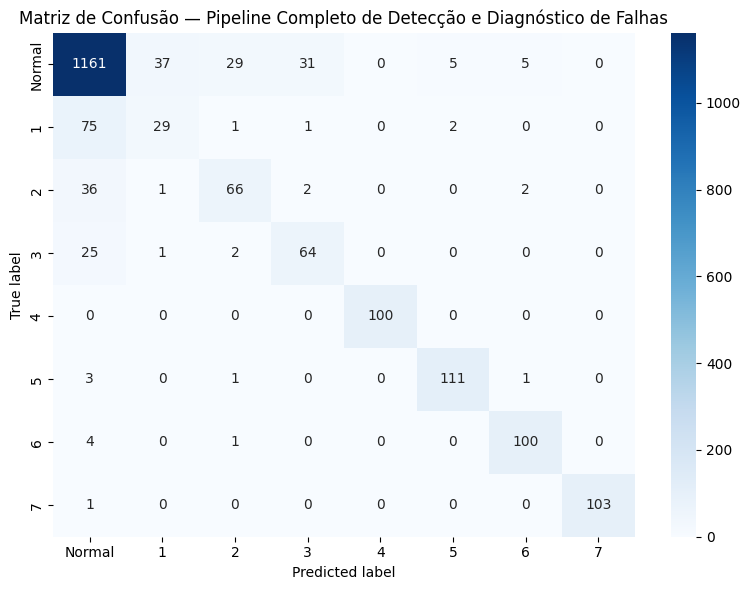

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi_top))

### Threshold Adjustment Configuration

#### 1º Version

##### 1.Detection (Normal vs. Fault)

In [ ]:
recall_fault_scorer = make_scorer(recall_score, pos_label=1)
tscv = TimeSeriesSplit(n_splits=3)

neg = (y_train_bin == 0).sum()
pos = (y_train_bin == 1).sum()
scale_pos_weight = neg / max(pos, 1)

xgb_detector = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight
)

param_dist_detector = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.03, 0.25),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0.0, 0.5),
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.0),
}

search = RandomizedSearchCV(
    estimator=xgb_detector,
    param_distributions=param_dist_detector,
    n_iter=30,
    scoring=recall_fault_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train_bin)
best_xgb_detector = search.best_estimator_

print("\nMelhores parâmetros (Detector XGB):")
print(search.best_params_)
print(f"Melhor recall médio (CV) - Falha=1: {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Melhores parâmetros (Detector XGB):
{'colsample_bytree': np.float64(0.8469926038510867), 'gamma': np.float64(0.30582658024414044), 'learning_rate': np.float64(0.03176657630492935), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 674, 'reg_alpha': np.float64(0.6118528947223795), 'reg_lambda': np.float64(0.7789877213040837), 'subsample': np.float64(0.7168578594140873)}
Melhor recall médio (CV) - Falha=1: 0.7684


In [ ]:
proba_val = best_xgb_detector.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)

rows = []
for t in thresholds:
    y_pred_t = (proba_val >= t).astype(int)

    rec = recall_score(y_val_bin, y_pred_t, zero_division=0)
    prec = precision_score(y_val_bin, y_pred_t, zero_division=0)
    f1 = f1_score(y_val_bin, y_pred_t, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_val_bin, y_pred_t).ravel()

    rows.append({
        "threshold": t,
        "recall_fault": rec,
        "precision_fault": prec,
        "f1_fault": f1,
        "FP": fp,
        "FN": fn
    })

df_thr = pd.DataFrame(rows)

# 1) ver top thresholds por recall
df_thr.sort_values("recall_fault", ascending=False).head(10)

,threshold,recall_fault,precision_fault,f1_fault,FP,FN
0,0.05,1.000000,0.349675,0.518162,1300,0
1,0.10,0.981402,0.413253,0.581602,974,13
2,0.15,0.955651,0.524745,0.677485,605,31
3,0.20,0.922747,0.602804,0.729226,425,54
4,0.25,0.904149,0.660397,0.763285,325,67
5,0.30,0.876967,0.713620,0.786906,246,86
6,0.35,0.851216,0.749370,0.797053,199,104
7,0.40,0.828326,0.775100,0.800830,168,120
8,0.45,0.809728,0.808571,0.809149,134,133
9,0.50,0.798283,0.835329,0.816386,110,141


In [ ]:
df_ok = df_thr[df_thr["FP"] <= 150]
best_row = df_ok.loc[df_ok["recall_fault"].idxmax()]

best_row

,8
threshold,0.450000
recall_fault,0.809728
precision_fault,0.808571
f1_fault,0.809149
FP,134.000000
FN,133.000000


In [ ]:
threshold_opt = float(best_row["threshold"])
print("Threshold escolhido:", threshold_opt)

Threshold escolhido: 0.45


In [ ]:
proba_test = best_xgb_detector.predict_proba(X_test)[:, 1]
y_test_pred = (proba_test >= threshold_opt).astype(int)

print("\n=== DETECTOR XGB (TESTE) com threshold calibrado ===")
print(classification_report(y_test_bin, y_test_pred, digits=4))


=== DETECTOR XGB (TESTE) com threshold calibrado ===
              precision    recall  f1-score   support

           0     0.8935    0.8998    0.8967      1268
           1     0.8243    0.8142    0.8192       732

    accuracy                         0.8685      2000
   macro avg     0.8589    0.8570    0.8580      2000
weighted avg     0.8682    0.8685    0.8683      2000



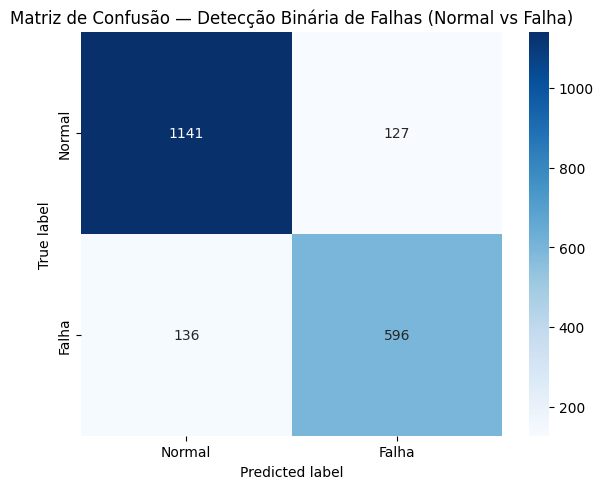

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, y_test_pred))

##### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

y_train_faults_0 = (y_train_faults - 1).astype(int)
y_test_faults_0  = (y_test_faults_true - 1).astype(int)

search.fit(X_train_faults, y_train_faults_0)

best_xgb_faults = search.best_estimator_

print("\nMelhores parâmetros (Detector):")
print(search.best_params_)
print(f"Melhor recall médio (CV) - Falha=1: {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:36:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Melhores parâmetros (Detector):
{'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.21299848545285127), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 321, 'reg_alpha': np.float64(0.15599452033620265), 'reg_lambda': np.float64(0.6161672243363989), 'subsample': np.float64(0.9464704583099741)}
Melhor recall médio (CV) - Falha=1: nan


In [ ]:
proba_test_faults = best_xgb_faults.predict_proba(X_test_faults_true)
pred_test_faults_0 = np.argmax(proba_test_faults, axis=1)
pred_test_faults = pred_test_faults_0 + 1

print("\n=== MODELO 2 (XGB): Diagnóstico 1–7 (apenas falhas reais no TESTE) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))


=== MODELO 2 (XGB): Diagnóstico 1–7 (apenas falhas reais no TESTE) ===
              precision    recall  f1-score   support

           1     0.8316    0.7315    0.7783       108
           2     0.8230    0.8692    0.8455       107
           3     0.8438    0.8804    0.8617        92
           4     1.0000    1.0000    1.0000       100
           5     0.9825    0.9655    0.9739       116
           6     0.9545    1.0000    0.9767       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9208       732
   macro avg     0.9193    0.9209    0.9194       732
weighted avg     0.9203    0.9208    0.9199       732



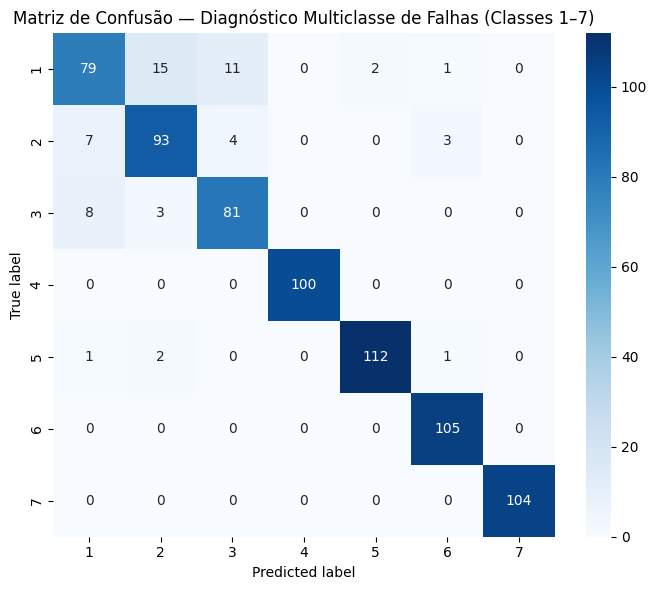

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults))

#####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
proba_test = best_xgb_detector.predict_proba(X_test)[:, 1]
pred_bin_test = (proba_test >= threshold_opt).astype(int)

final_pred_multi = np.zeros(len(X_test), dtype=int)

idx_pred_fault = np.where(pred_bin_test == 1)[0]

if len(idx_pred_fault) > 0:
    pred_faults_0 = best_xgb_faults.predict(X_test.iloc[idx_pred_fault])
    final_pred_multi[idx_pred_fault] = pred_faults_0 + 1

print("\n=== PIPELINE COMPLETO (Detector XGB + Diagnóstico XGB) no TESTE ===")
print(classification_report(y_test_multi, final_pred_multi, digits=4))


=== PIPELINE COMPLETO (Detector XGB + Diagnóstico XGB) no TESTE ===
              precision    recall  f1-score   support

           0     0.8935    0.8998    0.8967      1268
           1     0.3951    0.2963    0.3386       108
           2     0.6408    0.6168    0.6286       107
           3     0.6321    0.7283    0.6768        92
           4     1.0000    1.0000    1.0000       100
           5     0.9174    0.9569    0.9367       116
           6     0.9174    0.9524    0.9346       105
           7     1.0000    0.9904    0.9952       104

    accuracy                         0.8600      2000
   macro avg     0.7995    0.8051    0.8009      2000
weighted avg     0.8545    0.8600    0.8567      2000



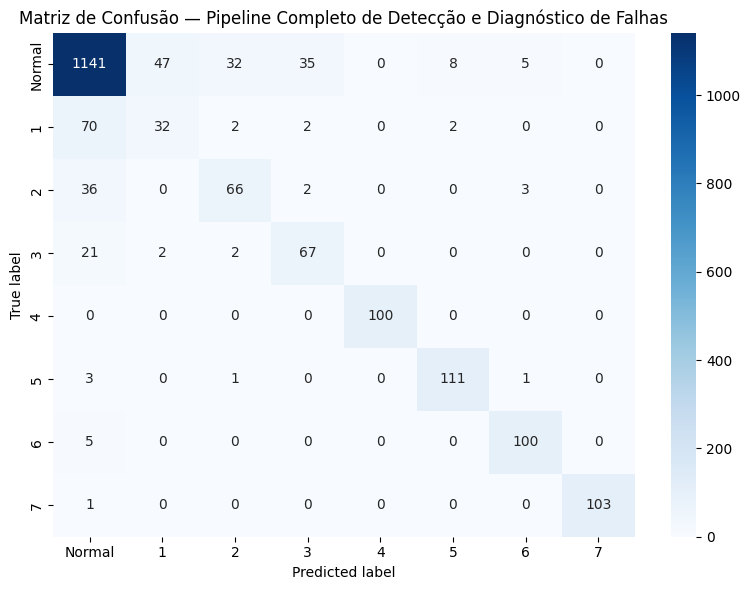

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi))

#### 2º Version (Varying the threshold)

In [ ]:
def build_threshold_table(y_true_bin, proba_fault, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)

    rows = []
    for t in thresholds:
        y_pred = (proba_fault >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred).ravel()

        rows.append({
            "threshold": float(t),
            "recall_fault": recall_score(y_true_bin, y_pred, zero_division=0),
            "precision_fault": precision_score(y_true_bin, y_pred, zero_division=0),
            "f1_fault": f1_score(y_true_bin, y_pred, zero_division=0),
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        })
    return pd.DataFrame(rows)

def pick_threshold_under_fp(df_thr, fp_limit):
    df_ok = df_thr[df_thr["FP"] <= fp_limit].copy()
    if df_ok.empty:
        return None  # não existe threshold que respeite esse limite
    # Escolhe o melhor recall; desempate: maior F1; depois maior precisão; depois maior threshold
    df_ok = df_ok.sort_values(
        by=["recall_fault", "f1_fault", "precision_fault", "threshold"],
        ascending=[False, False, False, False]
    )
    return df_ok.iloc[0]

In [ ]:
fp_limits = [100, 125, 150, 175, 200, 300]

# Probabilidades na validação (classe 1 = falha)
proba_val = best_xgb_detector.predict_proba(X_val)[:, 1]

# Tabela única de thresholds (val)
thresholds = np.arange(0.05, 0.96, 0.05)
df_thr = build_threshold_table(y_val_bin, proba_val, thresholds=thresholds)

results = []

# Probabilidades no teste (para avaliar depois)
proba_test = best_xgb_detector.predict_proba(X_test)[:, 1]

for lim in fp_limits:
    best_row = pick_threshold_under_fp(df_thr, fp_limit=lim)

    if best_row is None:
        results.append({
            "fp_limit": lim,
            "status": "SEM SOLUÇÃO (nenhum threshold atende FP)",
        })
        continue

    threshold_opt = float(best_row["threshold"])

    # Avaliar no teste com esse threshold
    y_test_pred = (proba_test >= threshold_opt).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_bin, y_test_pred).ravel()

    results.append({
        "fp_limit": lim,
        "threshold_opt": threshold_opt,
        # métricas no TESTE
        "test_recall_fault": recall_score(y_test_bin, y_test_pred, zero_division=0),
        "test_precision_fault": precision_score(y_test_bin, y_test_pred, zero_division=0),
        "test_f1_fault": f1_score(y_test_bin, y_test_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test_bin, y_test_pred),
        "test_TN": int(tn), "test_FP": int(fp), "test_FN": int(fn), "test_TP": int(tp),
        # também guardo como ficou na VAL, pra você comparar
        "val_recall_fault": float(best_row["recall_fault"]),
        "val_precision_fault": float(best_row["precision_fault"]),
        "val_f1_fault": float(best_row["f1_fault"]),
        "val_FP": int(best_row["FP"]),
        "val_FN": int(best_row["FN"]),
    })

df_sweep = pd.DataFrame(results)
df_sweep


,fp_limit,threshold_opt,test_recall_fault,test_precision_fault,test_f1_fault,test_accuracy,test_TN,test_FP,test_FN,test_TP,val_recall_fault,val_precision_fault,val_f1_fault,val_FP,val_FN
0,100,0.55,0.790984,0.869369,0.828326,0.8800,1181,87,153,579,0.783977,0.860283,0.820359,89,151
1,125,0.50,0.807377,0.851585,0.828892,0.8780,1165,103,141,591,0.798283,0.835329,0.816386,110,141
2,150,0.45,0.814208,0.824343,0.819244,0.8685,1141,127,136,596,0.809728,0.808571,0.809149,134,133
3,175,0.40,0.838798,0.798440,0.818121,0.8635,1113,155,118,614,0.828326,0.775100,0.800830,168,120
4,200,0.35,0.856557,0.764634,0.807990,0.8510,1075,193,105,627,0.851216,0.749370,0.797053,199,104
5,300,0.30,0.877049,0.724605,0.793572,0.8330,1024,244,90,642,0.876967,0.713620,0.786906,246,86


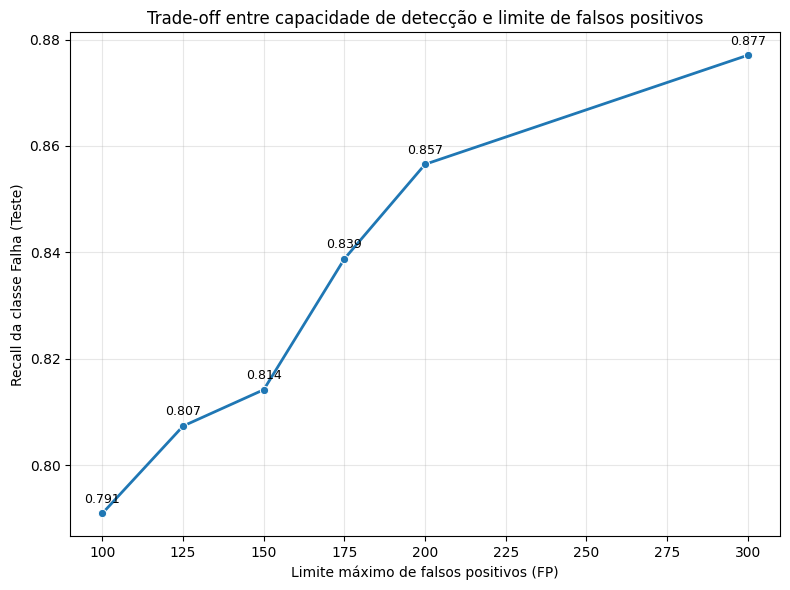

In [ ]:
# garantir ordenação
df_plot = df_sweep.sort_values("fp_limit")

plt.figure(figsize=(8,6))

sns.lineplot(
    data=df_plot,
    x="fp_limit",
    y="test_recall_fault",
    marker="o",
    linewidth=2
)

plt.xlabel("Limite máximo de falsos positivos (FP)")
plt.ylabel("Recall da classe Falha (Teste)")
plt.title("Trade-off entre capacidade de detecção e limite de falsos positivos")

plt.grid(True, alpha=0.3)

# opcional: destacar pontos
for _, row in df_plot.iterrows():
    plt.text(
        row["fp_limit"],
        row["test_recall_fault"] + 0.002,
        f"{row['test_recall_fault']:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

##### 1.Detection (Normal vs. Fault)

In [ ]:
proba_test = best_xgb_detector.predict_proba(X_test)[:, 1]
y_test_pred = (proba_test >= 0.3).astype(int)

print("\n=== DETECTOR XGB (TESTE) com threshold calibrado ===")
print(classification_report(y_test_bin, y_test_pred, digits=4))


=== DETECTOR XGB (TESTE) com threshold calibrado ===
              precision    recall  f1-score   support

           0     0.9192    0.8076    0.8598      1268
           1     0.7246    0.8770    0.7936       732

    accuracy                         0.8330      2000
   macro avg     0.8219    0.8423    0.8267      2000
weighted avg     0.8480    0.8330    0.8355      2000



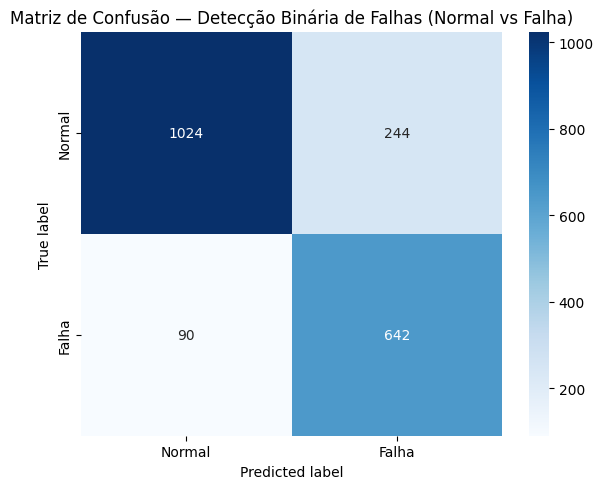

In [ ]:
plot_matrix_bin(confusion_matrix(y_test_bin, y_test_pred))

##### 2.Diagnosis (Which fault? 1–7)
Train ONLY with fault samples (Fault_Label != 0)

In [ ]:
train_fault_mask = (y_train_multi != 0)
test_fault_mask  = (y_test_multi != 0)

X_train_faults = X_train.loc[train_fault_mask]
y_train_faults = y_train_multi.loc[train_fault_mask]

X_test_faults_true = X_test.loc[test_fault_mask]
y_test_faults_true = y_test_multi.loc[test_fault_mask]

y_train_faults_0 = (y_train_faults - 1).astype(int)
y_test_faults_0  = (y_test_faults_true - 1).astype(int)

search.fit(X_train_faults, y_train_faults_0)

best_xgb_faults = search.best_estimator_

print("\nMelhores parâmetros (Detector):")
print(search.best_params_)
print(f"Melhor recall médio (CV) - Falha=1: {search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:37:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Melhores parâmetros (Detector):
{'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.21299848545285127), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 321, 'reg_alpha': np.float64(0.15599452033620265), 'reg_lambda': np.float64(0.6161672243363989), 'subsample': np.float64(0.9464704583099741)}
Melhor recall médio (CV) - Falha=1: nan


In [ ]:
proba_test_faults = best_xgb_faults.predict_proba(X_test_faults_true)
pred_test_faults_0 = np.argmax(proba_test_faults, axis=1)
pred_test_faults = pred_test_faults_0 + 1

print("\n=== MODELO 2 (XGB): Diagnóstico 1–7 (apenas falhas reais no TESTE) ===")
print(classification_report(y_test_faults_true, pred_test_faults, digits=4))


=== MODELO 2 (XGB): Diagnóstico 1–7 (apenas falhas reais no TESTE) ===
              precision    recall  f1-score   support

           1     0.8316    0.7315    0.7783       108
           2     0.8230    0.8692    0.8455       107
           3     0.8438    0.8804    0.8617        92
           4     1.0000    1.0000    1.0000       100
           5     0.9825    0.9655    0.9739       116
           6     0.9545    1.0000    0.9767       105
           7     1.0000    1.0000    1.0000       104

    accuracy                         0.9208       732
   macro avg     0.9193    0.9209    0.9194       732
weighted avg     0.9203    0.9208    0.9199       732



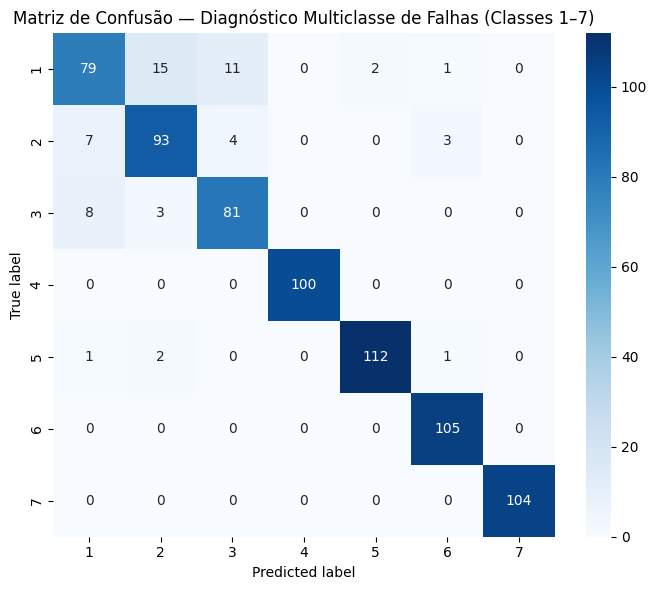

In [ ]:
plot_matrix_multiclass(confusion_matrix(y_test_faults_true, pred_test_faults))

#####  3.Evaluation of the complete pipeline (simulating real-world usage)

*   first, the detector determines whether it is a fault
*   if a fault is detected, the classifier determines which fault it is

In [ ]:
proba_test = best_xgb_detector.predict_proba(X_test)[:, 1]
pred_bin_test = (proba_test >= threshold_opt).astype(int)

final_pred_multi = np.zeros(len(X_test), dtype=int)

idx_pred_fault = np.where(pred_bin_test == 1)[0]

if len(idx_pred_fault) > 0:
    pred_faults_0 = best_xgb_faults.predict(X_test.iloc[idx_pred_fault])
    final_pred_multi[idx_pred_fault] = pred_faults_0 + 1

print("\n=== PIPELINE COMPLETO (Detector XGB + Diagnóstico XGB) no TESTE ===")
print(classification_report(y_test_multi, final_pred_multi, digits=4))


=== PIPELINE COMPLETO (Detector XGB + Diagnóstico XGB) no TESTE ===
              precision    recall  f1-score   support

           0     0.9192    0.8076    0.8598      1268
           1     0.3185    0.4630    0.3774       108
           2     0.5168    0.7196    0.6016       107
           3     0.5106    0.7826    0.6180        92
           4     1.0000    1.0000    1.0000       100
           5     0.8880    0.9569    0.9212       116
           6     0.9189    0.9714    0.9444       105
           7     1.0000    0.9904    0.9952       104

    accuracy                         0.8195      2000
   macro avg     0.7590    0.8364    0.7897      2000
weighted avg     0.8529    0.8195    0.8309      2000



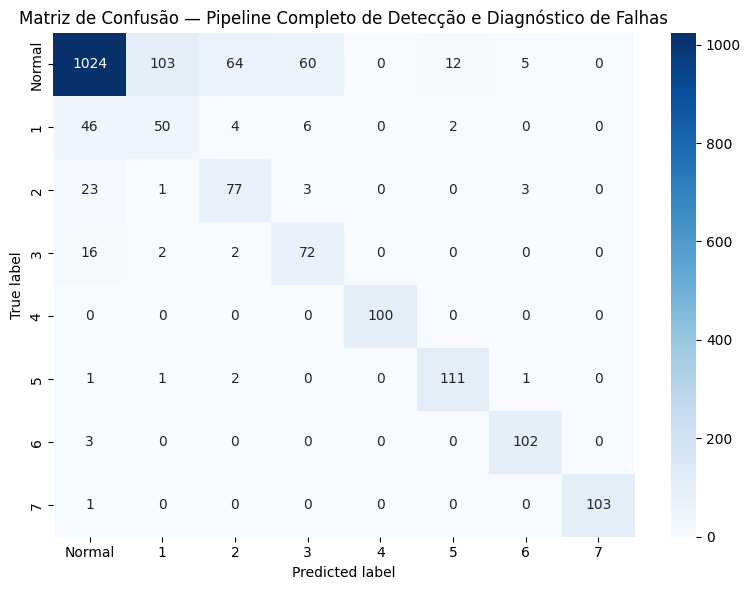

In [ ]:
plot_matrix_pipeline(confusion_matrix(y_test_multi, final_pred_multi))